In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
from itertools import product
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output
import matplotlib.colors as mcolors
#import build_H_with_parameters

In [2]:
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'

In [3]:
one = np.array([[1., 0.],[0.,1.]], dtype=np.float64)
pauli_1 = np.array([[0.,1.],[1.,0.]], dtype=np.float64)
pauli_2 = np.array([[0., 0-1j],[0 +1j, 0.]], dtype=np.complex64)
pauli_3 = np.array([[1.,0.],[0., -1.]], dtype=np.float64)
plus = (1/2 * (pauli_1 + 1.j * pauli_2)).real
minus = (1/2 * (pauli_1 - 1.j * pauli_2)).real

In [4]:
print(pauli_2.dtype)

complex64


In [5]:
def Get_H(m, number_of_qubits):
    res_XY = torch.zeros((2**number_of_qubits, 2**number_of_qubits), dtype = torch.float64)
    res_mass = torch.zeros((2**number_of_qubits, 2**number_of_qubits), dtype = torch.float64)
    res_iter = torch.zeros((2**number_of_qubits, 2**number_of_qubits), dtype = torch.float64)


    # XY term
    first = one
    for i in range(1,number_of_qubits):
        #print(i)
        first = one
        second = one
        for j in range(1, number_of_qubits -i-1):
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        if i != number_of_qubits - 1 :
            first = TensorProduct(minus, first)
            first = TensorProduct(plus, first)
            second = TensorProduct(plus, second)
            second = TensorProduct(minus, second)
        else:
            first = TensorProduct(plus, minus)
            second = TensorProduct(minus, plus)
        for j in range(1,i):
            #print("uu")
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        #print(c.size())
        res_XY += torch.from_numpy(first + second)

    #print(res_XY)

    # mass term
    for i in range(1, number_of_qubits + 1):
        mass = one
        for j in range(1, number_of_qubits - i):
            mass = TensorProduct(one, mass)
        if i == number_of_qubits:
            mass = pauli_3
        else:
            mass = TensorProduct(pauli_3, mass)
        for j in range(1, i):
            mass = TensorProduct(one, mass)
    
        res_mass += (-1)**i * (torch.from_numpy(mass))
    
       
    #print(res_mass)

    # iteraction term
    for i in range(1,number_of_qubits ):
        res_ite = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        res_ones = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        for j in range(1, i + 1):
        
            ite = one
        
            for k in range(1, number_of_qubits - j):
                ite = TensorProduct(one, ite)
            if j == number_of_qubits:
                ite = pauli_3
            else:
                ite = TensorProduct(pauli_3, ite)
            for k in range(1, j):
                ite = TensorProduct(one, ite)
            res_ite += (torch.from_numpy(ite)) 
            ones = one
        
            for k in range(1,number_of_qubits):
                ones = TensorProduct(one, ones)
            res_ones += (-1)**j*(torch.from_numpy(ones))
        #print(torch.matmul(res_ones + res_ite, res_ones + res_ite)) 
        res_iter += torch.matmul(res_ones + res_ite, res_ones + res_ite)   
    
    #print(res_mass)
    return   1/4*res_iter + res_XY + m/2*res_mass

In [6]:
def int10tobase_torch(num,base=2):
  c = num
  max_digit = nq-1
  res = torch.zeros((max_digit+1,num.shape[0]),dtype = torch.long)
  i = max_digit
  while(torch.sum(c)!=0):
    res[i,:] = torch.remainder(c,base)
    c = (c/base).type(torch.long)
    i-=1
  return res.t()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: UserWarning: torch.eig is deprecated in favor of torch.linalg.eig and will be removed in a future PyTorch release.
torch.linalg.eig returns complex tensors of dtype cfloat or cdouble rather than real tensors mimicking complex tensors.
L, _ = torch.eig(A)
should be replaced with
L_complex = torch.linalg.eigvals(A)
and
L, V = torch.eig(A, eigenvectors=True)
should be replaced with
L_complex, V_complex = torch.linalg.eig(A) (Triggered internally at  /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2897.)
  


tensor(-2.8615, dtype=torch.float64) tensor(-2.2414, dtype=torch.float64) tensor(-0.8774, dtype=torch.float64) tensor(-0.6403, dtype=torch.float64) tensor(-0.4529, dtype=torch.float64) tensor(-0.3364, dtype=torch.float64)
tensor([[[0., 0., 1., 1., 0., 1.]],

        [[0., 1., 0., 0., 1., 1.]],

        [[0., 1., 0., 1., 0., 1.]],

        [[0., 1., 0., 1., 1., 0.]],

        [[0., 1., 1., 0., 0., 1.]],

        [[1., 0., 0., 1., 0., 1.]]])


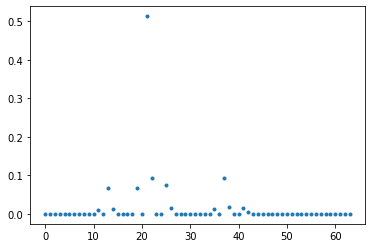

tensor([24])
tensor([0., 1., 0., 1., 0., 0.])


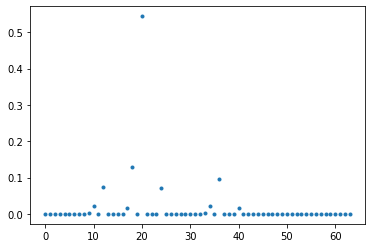

tensor([[[0., 0., 1., 1., 1., 1.]],

        [[0., 1., 0., 1., 1., 1.]],

        [[0., 1., 1., 0., 1., 1.]],

        [[1., 0., 0., 1., 1., 1.]]])


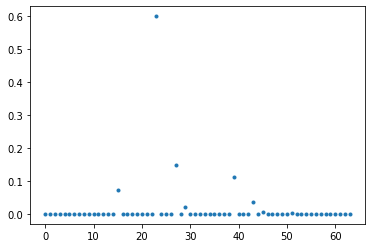

tensor([[[0., 0., 1., 0., 1., 1.]],

        [[0., 0., 1., 1., 0., 1.]],

        [[0., 1., 0., 0., 1., 1.]],

        [[0., 1., 0., 1., 1., 0.]],

        [[0., 1., 1., 0., 0., 1.]],

        [[0., 1., 1., 0., 1., 0.]],

        [[1., 0., 0., 1., 0., 1.]],

        [[1., 0., 0., 1., 1., 0.]],

        [[1., 0., 1., 0., 0., 1.]]])


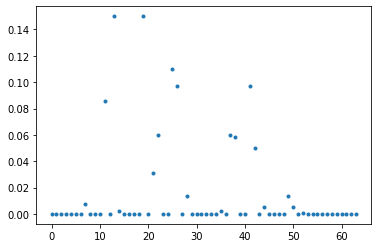

In [ ]:
H = Get_H(0.3,6).type(torch.float64)
nq = 6
x = torch.arange(2**nq)
basis = int10tobase_torch(x).type(torch.float32)
#R = basis[]
values, vectors = torch.eig(H, eigenvectors = True)
eig_values = values[:, 0]
eig_vector = vectors
t,y = eig_values.sort()
#print(t,y)
print(t[0], t[1], t[2],  t[3],  t[4], t[5])
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(-1)
w = (R**2 > 0.05).nonzero()
print(basis[w])
plt.plot(R**2,'.')
#print(R[21]**2)
plt.show()

R1 = eig_vector[:,y[1]].reshape(-1)
plt.plot(R1**2,'.')
w = (R1**2 > 0.05).nonzero()
print(w[3])
print(basis[20])
plt.show()
R1 = eig_vector[:,y[2]].reshape(-1)
plt.plot(R1**2,'.')
w = (R1**2 > 0.05).nonzero()
print(basis[w])
plt.show()
R1 = eig_vector[:,y[3]].reshape(-1)
plt.plot(R1**2,'.')
w = (R1**2 > 0.05).nonzero()
print(basis[w])

In [ ]:
def Good_vectors_1st_ex(nq):
    sum_spin = math.ceil((nq - 1) / 2  - 1)
    good_vectors = basis.sum(dim = 1)
    good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
    sub_batch = torch.zeros(good_vectors.shape[0], nq)
    i = torch.arange(0, good_vectors.shape[0], 1)
    #print(i.shape, good_vectors.shape)
    sub_batch[i, :] = basis[good_vectors, :]
    good_batch = sub_batch
    a = 2**torch.arange(nq -1, -1,-1)
    num_batch = good_batch*a 
    num_batch = num_batch.sum(dim = 1)

    return good_vectors, good_batch, num_batch

In [ ]:
nq = 10
x = torch.arange(2**nq)
basis = int10tobase_torch(x).type(torch.float32)
good_vectors, good_batch, num_batch = Good_vectors_1st_ex(nq)
print(good_batch[5])

tensor([0., 0., 0., 0., 1., 0., 0., 1., 1., 1.])


tensor([[212],
        [308],
        [332],
        [338],
        [340],
        [344],
        [356],
        [404],
        [596]])
tensor([4.3477], dtype=torch.float64)
tensor(-4.3477, dtype=torch.float64)


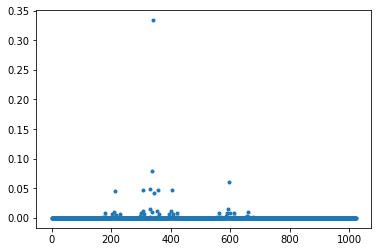

tensor([[[0., 0., 1., 1., 0., 1., 0., 1., 0., 0.]],

        [[0., 1., 0., 0., 1., 1., 0., 1., 0., 0.]],

        [[0., 1., 0., 1., 0., 0., 1., 1., 0., 0.]],

        [[0., 1., 0., 1., 0., 1., 0., 0., 1., 0.]],

        [[0., 1., 0., 1., 0., 1., 0., 1., 0., 0.]],

        [[0., 1., 0., 1., 0., 1., 1., 0., 0., 0.]],

        [[0., 1., 0., 1., 1., 0., 0., 1., 0., 0.]],

        [[0., 1., 1., 0., 0., 1., 0., 1., 0., 0.]],

        [[1., 0., 0., 1., 0., 1., 0., 1., 0., 0.]]])


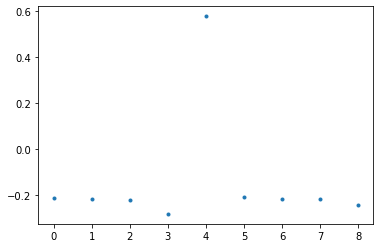

In [ ]:
psi = torch.zeros(2**nq, dtype = torch.float64)
#psi[84] = 1
nq = 10
H = Get_H(0.3,nq)#.type(torch.float64)
x = torch.arange(2**nq)
basis = int10tobase_torch(x).type(torch.float32)
values, vectors = torch.eig(H, eigenvectors = True)
eig_values = values[:, 0]
eig_vector = vectors
t,y = eig_values.sort()
R1 = eig_vector[:,y[1]].reshape(-1)
plt.plot(R1**2,'.')
w = (R1**2 > 0.03).nonzero()
print(w)
print(+0.3/2*(nq - 2) - R1[w].sum()/R1[w[4]] + 1)
print(t[1])
plt.show()
plt.plot(R1[w],'.')
print(basis[w])

In [ ]:
H = Get_H(1,4)
print(H)

tensor([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0., -2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0., -2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0., -4.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -2.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 

In [ ]:
def circle():
    distance = []
    distance.append(0)
    distance.append(0)
    E = []
    E.append(0)
    E.append(0)
    for number_of_qubits in range(2,5):
        basis = torch.zeros(2**number_of_qubits,number_of_qubits)
        r = 2**number_of_qubits - 1
        #r = 0
        for p in product('10', repeat= number_of_qubits):
            for i in range(number_of_qubits):
                #print(p[i])
                #if(float(p[i]) == 0):
                #    basis[r][i] = -1
                #else:
                basis[r][i] = float(p[i])
            r -= 1

        m = -1.7
        H = Get_H(m, number_of_qubits)
        
        eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
        eig_vector = torch.eig(H, eigenvectors = True)[1]
        c = eig_values.min()
        k = torch.min(eig_values,0)[1]
        R = eig_vector[:,k].reshape(2**number_of_qubits)

        distr = R**2
        distr = distr.view(2**number_of_qubits, 1)
        n = distr.max()
        n = (n == distr).nonzero()[:,0]

        place = (distr**2 > 0.0000001).nonzero()
        #print(place.shape[0])
        distance.append(place.shape[0])
        print(number_of_qubits)
        #print(place.shape[0], 'nonzero elements')
        #print(distr.max(), 'pick')
        #print(c, 'ground state')
        E.append(c)
        x = np.arange(0,2**number_of_qubits)
        a = distr
        fig, ax = plt.subplots()
        ax.plot(x, R**2,'.')
        ax.legend()
        plt.show()
    plt.plot(distance)

    np.save('number_of_qubits_{}'.format( number_of_qubits), R)

    plt.show()
    return E

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:24: UserWarning: torch.eig is deprecated in favor of torch.linalg.eig and will be removed in a future PyTorch release.
torch.linalg.eig returns complex tensors of dtype cfloat or cdouble rather than real tensors mimicking complex tensors.
L, _ = torch.eig(A)
should be replaced with
L_complex = torch.linalg.eigvals(A)
and
L, V = torch.eig(A, eigenvectors=True)
should be replaced with
L_complex, V_complex = torch.linalg.eig(A) (Triggered internally at  /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2897.)
No handles with labels found to put in legend.


tensor([[ 0.,  0.,  0.,  0.],
        [ 0., -2.,  0.,  0.],
        [ 0.,  0.,  2.,  0.],
        [ 0.,  0.,  0.,  0.]])
2


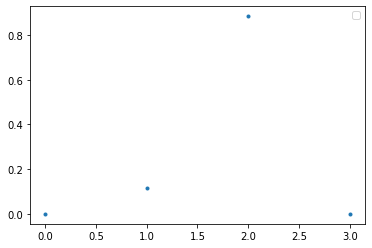

No handles with labels found to put in legend.


tensor([[-1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., -3.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., -1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  3.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]])
3


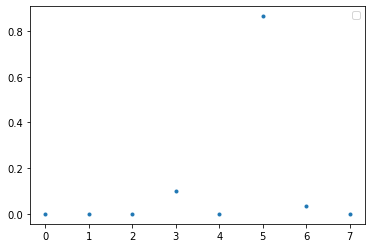

No handles with labels found to put in legend.


tensor([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0., -2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0., -2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0., -4.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -2.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 

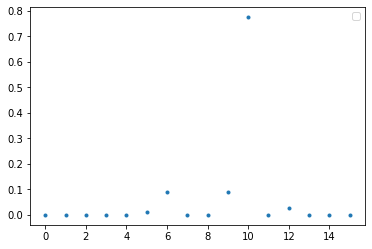

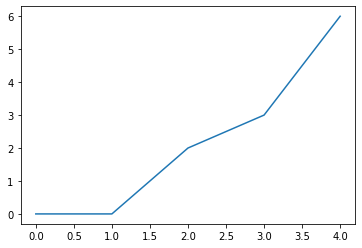

In [ ]:
Gr_st = circle()

In [ ]:
m = -1.7
number_of_qubits = 12
H = Get_H(m, number_of_qubits)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
k = torch.min(eig_values,0)[1]
R = eig_vector[:,k].reshape(2**number_of_qubits)


tensor([[ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0., -2.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  2.,  ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.,  ..., -2.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  2.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.]])


tensor([[ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0., -2.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  2.,  ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.,  ..., -2.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  2.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.]])


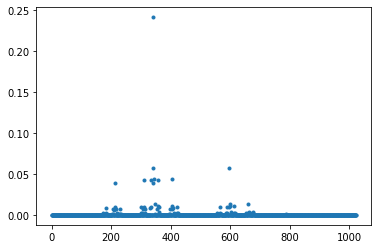

In [ ]:
m = 0.1
number_of_qubits = 10
H = Get_H(m, number_of_qubits)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
k = torch.min(eig_values,0)[1]
R8 = eig_vector[:,k].reshape(2**number_of_qubits)
plt.plot(R8**2, '.')

tensor([[0.0000e+00, 4.5147e-16, 1.7072e-15, 5.8040e-01],
        [3.0179e-15, 8.7255e-02, 1.4261e-01, 0.0000e+00],
        [6.5987e-15, 1.4261e-01, 2.1457e-03, 0.0000e+00],
        [4.4990e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00]])


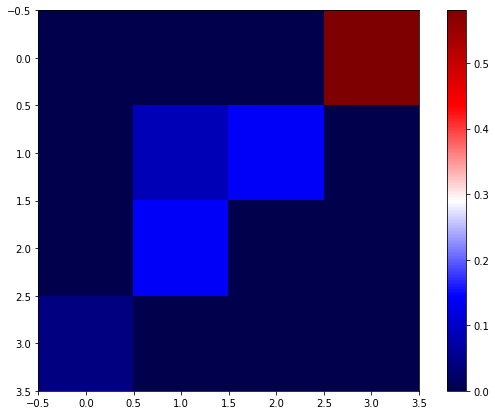

In [ ]:
t = torch.arange(16)
t = R8
t1 = t[:4].reshape(2,2)
t2 = t[4:8].reshape(2,2)
t3 = t[8:12].reshape(2,2)
t4 = t[12:16].reshape(2,2)
tt = torch.cat((t1,t2), dim = 1)
tt2 = torch.cat((t3,t4), dim = 1)
t = torch.cat((tt,tt2),0)
print(t**2)
plt.subplots(figsize=(10, 7))
plt.imshow(t**2,cmap = 'seismic')
plt.colorbar()

tensor([[ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0., -2.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  2.,  ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.,  ..., -2.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  2.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.]])
tensor([[ 0.0000e+00, -4.0394e-08, -1.0831e-08,  2.9147e-08,  8.5266e-09,
          1.7438e-07,  3.8048e-07,  2.4128e-01],
        [ 4.1312e-08,  1.1289e-09, -1.3402e-07, -1.3846e-02, -5.4865e-07,
         -1.1907e-01, -2.8100e-01, -6.5853e-08],
        [-2.1271e-09, -1.9370e-07, -4.0618e-07, -1.1907e-01, -2.4974e-07,
         -2.5174e-01, -8.1823e-02,  3.3898e-09],
        [ 5.9213e-07,  7.9750e-02,  1.2662e-01,  4.9970e-08,  3.5259e-01,
          7.8225e-09, -3.5330e-08, -1.6358e-09],
        [-2.5892e-08, -1.1164e-07, -3.7927e-07, -2.8100e-01, -1.3287e-07,
         -8.1823e-02, -3.1025e-02,  7.6322e-08],
        [ 5.8167e-07,  1.2662e-01,  3.3595e-01, -1.3313e-08,  1.1868e-01,
          2.0294e-09,

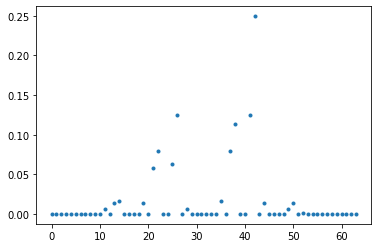

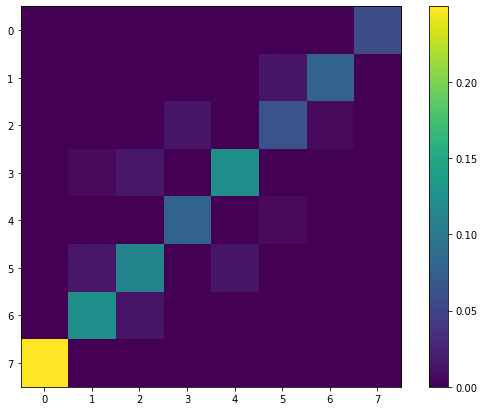

In [ ]:
m = -0.8
number_of_qubits = 6
H = Get_H(m, number_of_qubits)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
k = torch.min(eig_values,0)[1]
R8 = eig_vector[:,k].reshape(2**number_of_qubits)
plt.plot(R8**2, '.')
t = torch.arange(2**6)
t = R8
z = torch.zeros(math.ceil(t.shape[0]/4), 2,2)
for i in range(math.ceil(t.shape[0]/4)):
  z[i] = t[4*i:4*i + 4].reshape(2,2)
#print(z)
e = torch.zeros(math.ceil(t.shape[0]/8), 2, 4)
#print(e.shape)
for i in range(math.ceil(t.shape[0]/8)):
  e[i] = torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
z = torch.zeros(math.ceil(t.shape[0]/16), 4, 4)
for i in range(math.ceil(t.shape[0]/16)):
  z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
#print(z, 'z')
e = torch.zeros(math.ceil(t.shape[0]/32),4,8)
for i in range(math.ceil(t.shape[0]/32)):
  e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
res = torch.cat((e[0],e[1]) , 0)
print(res)
plt.subplots(figsize=(10, 7))
plt.imshow(res**2)
plt.colorbar()

tensor([[ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0., -2.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  2.,  ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.,  ..., -2.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  2.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.]])


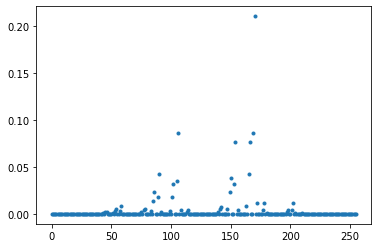

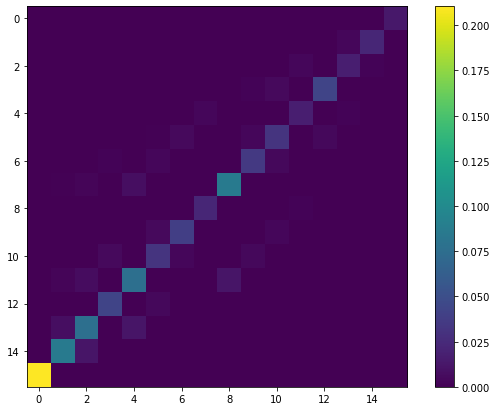

In [ ]:
m = -0.9
number_of_qubits = 8
H = Get_H(m, number_of_qubits)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
k = torch.min(eig_values,0)[1]
R8 = eig_vector[:,k].reshape(2**number_of_qubits)
plt.plot(R8**2, '.')
t = torch.arange(2**8)
t = R8
z = torch.zeros(math.ceil(t.shape[0]/4), 2,2)
for i in range(math.ceil(t.shape[0]/4)):
  z[i] = t[4*i:4*i + 4].reshape(2,2)
#print(z)
e = torch.zeros(math.ceil(t.shape[0]/8), 2, 4)
#print(e.shape)
for i in range(math.ceil(t.shape[0]/8)):
  e[i] = torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
z = torch.zeros(math.ceil(t.shape[0]/16), 4, 4)
for i in range(math.ceil(t.shape[0]/16)):
  z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
#print(z, 'z')
e = torch.zeros(math.ceil(t.shape[0]/32),4,8)
for i in range(math.ceil(t.shape[0]/32)):
  e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
z = torch.zeros(math.ceil(t.shape[0]/64), 8, 8)
for i in range(math.ceil(t.shape[0]/64)):
  z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
#print(z, 'z')
e = torch.zeros(math.ceil(t.shape[0]/128),8,16)
for i in range(math.ceil(t.shape[0]/128)):
  e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
res = torch.cat((e[0],e[1]) , 0)
#print(res)
plt.subplots(figsize=(10, 7))
plt.imshow(res**2)
plt.colorbar()

5
torch.Size([252]) torch.Size([252])


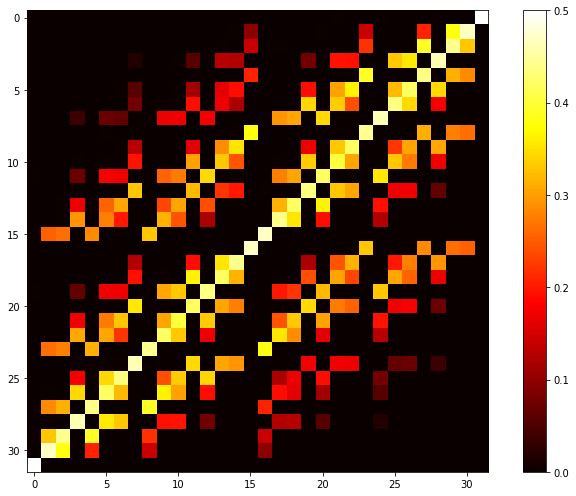

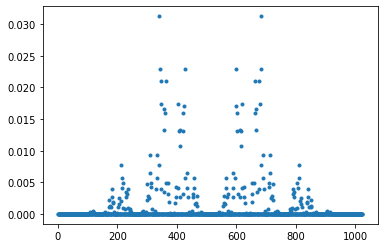

In [ ]:
  m = 0.1
  number_of_qubits = 10
  basis = torch.zeros(2**number_of_qubits,number_of_qubits)
  r = 2**number_of_qubits - 1
        #r = 0
  for p in product('10', repeat= number_of_qubits):
      for i in range(number_of_qubits):
        basis[r][i] = float(p[i])
      r -= 1
  sum_spin = math.ceil((number_of_qubits - 1) / 2 )
  print(sum_spin)
  good_vectors = basis.sum(dim = 1)
  good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
  #print(good_vectors)
  sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
  i = torch.arange(0, good_vectors.shape[0], 1)
  print(i.shape, good_vectors.shape)
  sub_batch[i, :] = basis[good_vectors, :]
  good_batch = sub_batch

  H = Get_H(m, number_of_qubits)
  #H = build_H_with_parameters.matrix(good_batch,m,1,number_of_qubits)
  eig_values, eig_vector = torch.eig(H, eigenvectors = True)#[0][:, 0]
  eig_values = eig_values[:,0]
  #eig_vector = torch.eig(H, eigenvectors = True)[1]
  k = torch.min(eig_values,0)[1]

  R = eig_vector[:,k].reshape(2**10)
  #R8 = torch.zeros(2**10)
  #i = torch.arange(252)
  #R8[good_vectors] = R[i]
  R8 = R
  #plt.plot(R8**2, '.')
  t = torch.arange(2**12)
  t = torch.arange(2**10)
  t = R8
  z = torch.zeros(math.ceil(t.shape[0]/4), 2,2)
  for i in range(math.ceil(t.shape[0]/4)):
    z[i] = t[4*i:4*i + 4].reshape(2,2)
  #print(z)
  e = torch.zeros(math.ceil(t.shape[0]/8), 2, 4)
  #print(e.shape)
  for i in range(math.ceil(t.shape[0]/8)):
    e[i] = torch.cat((z[2*i],z[2*i+1]), 1)
  #print(e)
  z = torch.zeros(math.ceil(t.shape[0]/16), 4, 4)
  for i in range(math.ceil(t.shape[0]/16)):
    z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
  #print(z, 'z')
  e = torch.zeros(math.ceil(t.shape[0]/32),4,8)
  for i in range(math.ceil(t.shape[0]/32)):
    e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
  #print(e)
  z = torch.zeros(math.ceil(t.shape[0]/64), 8, 8)
  for i in range(math.ceil(t.shape[0]/64)):
    z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
  #print(z, 'z')
  e = torch.zeros(math.ceil(t.shape[0]/128),8,16)
  for i in range(math.ceil(t.shape[0]/128)):
    e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
  #print(e)
  z = torch.zeros(math.ceil(t.shape[0]/256), 16, 16)
  for i in range(math.ceil(t.shape[0]/256)):
    z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
  #print(z, 'z')
  e = torch.zeros(math.ceil(t.shape[0]/512),16,32)
  for i in range(math.ceil(t.shape[0]/512)):
    e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
  #print(res[q].shape)
  res = torch.cat((e[0],e[1]) , 0)
  #print(res)
  
  plt.subplots(figsize=(10, 7))
  plt.imshow((res**2)**0.2,  cmap = 'hot')
  plt.colorbar()
  plt.tight_layout()
  plt.savefig('m'+str(m)+'hot.pdf')
  plt.show()
  
  plt.plot(R8**2,'.')

torch.Size([32, 32])


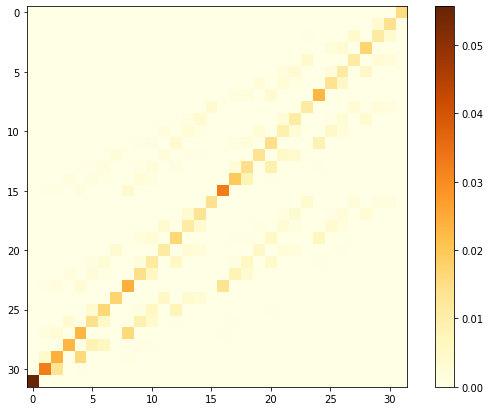

torch.Size([32, 32])


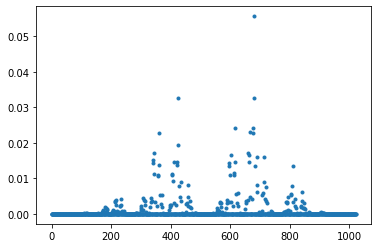

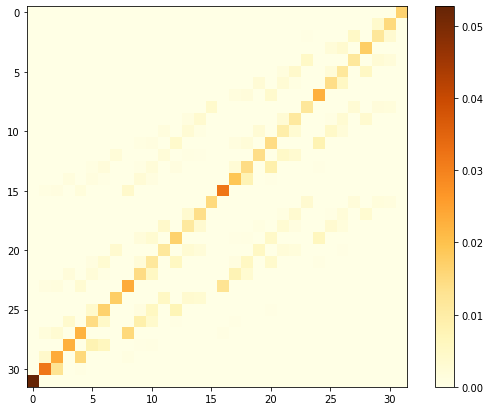

torch.Size([32, 32])


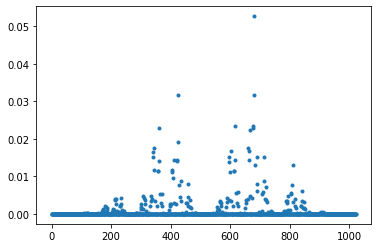

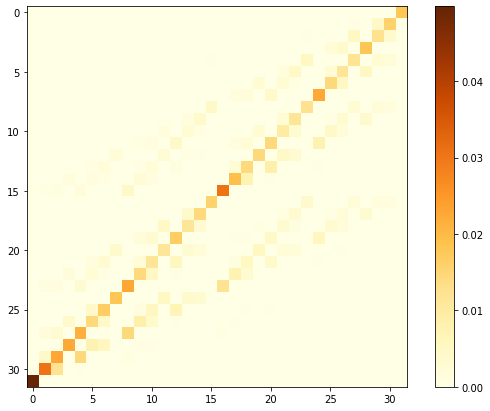

torch.Size([32, 32])


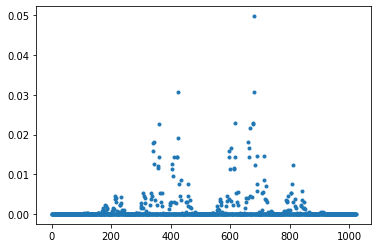

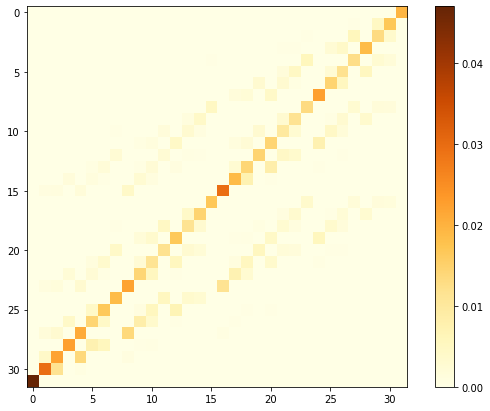

torch.Size([32, 32])


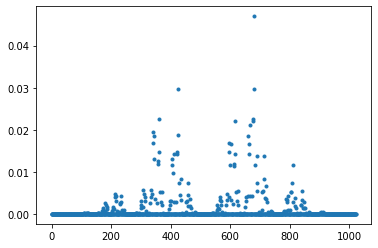

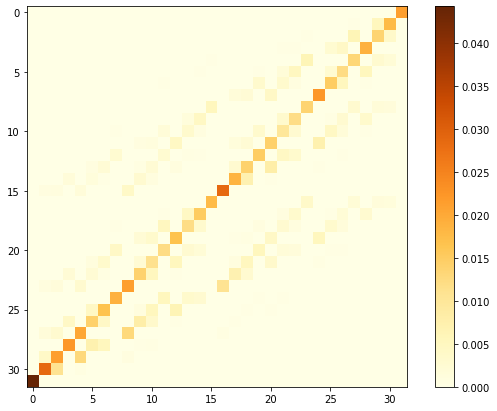

torch.Size([32, 32])


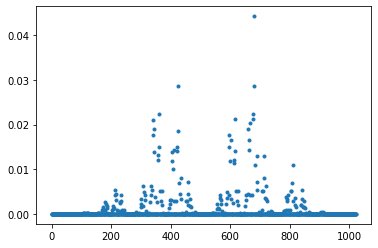

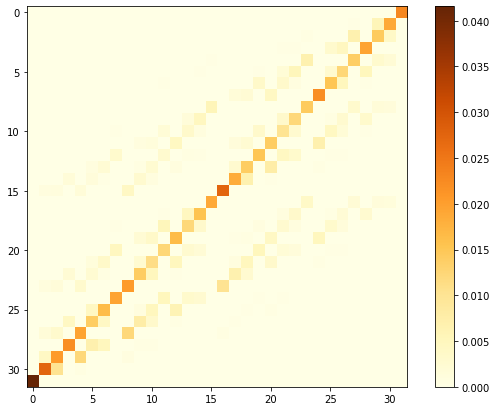

torch.Size([32, 32])


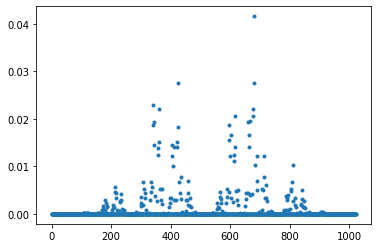

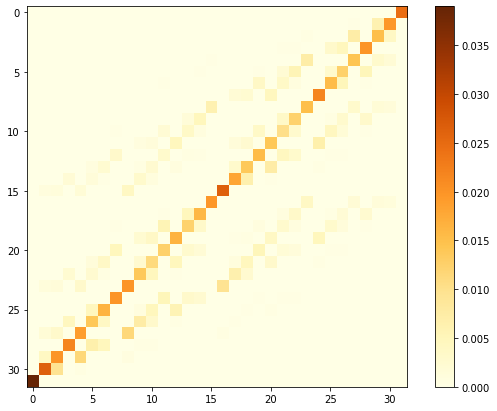

torch.Size([32, 32])


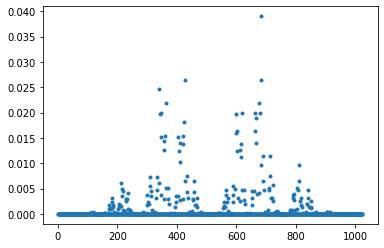

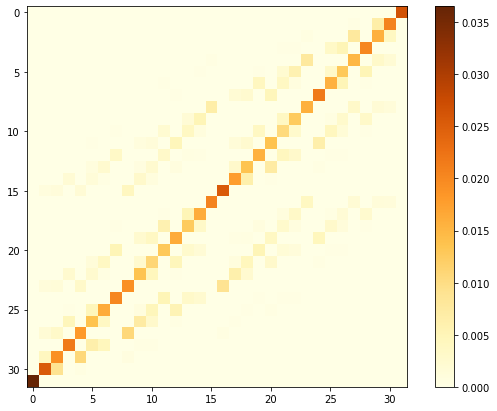

torch.Size([32, 32])


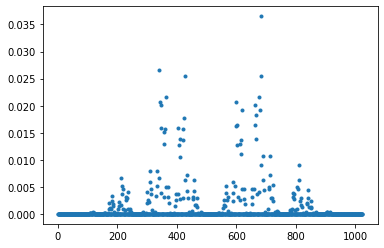

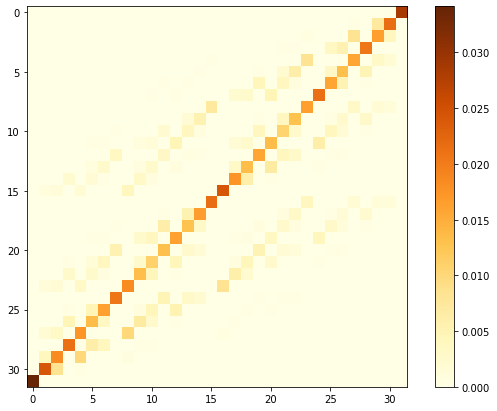

torch.Size([32, 32])


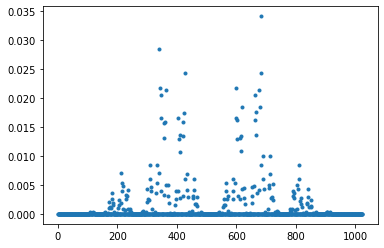

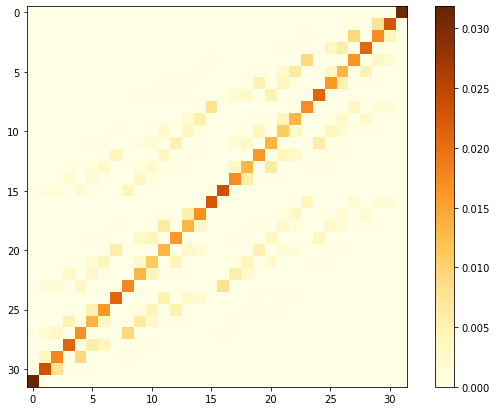

torch.Size([32, 32])


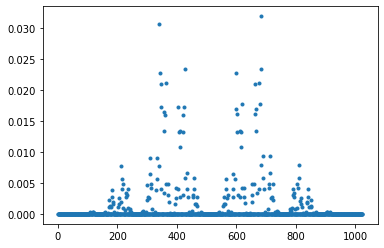

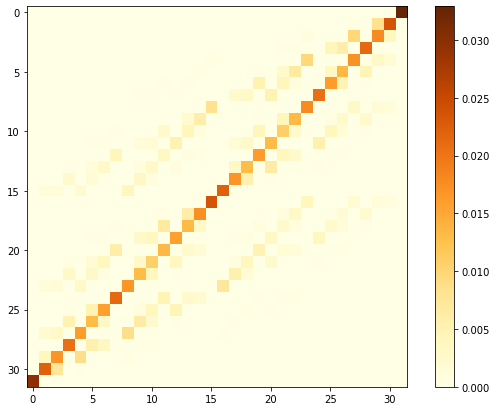

torch.Size([32, 32])


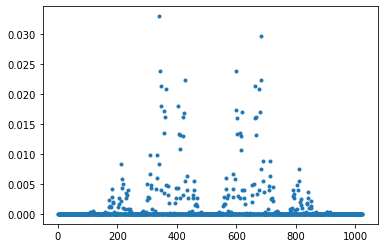

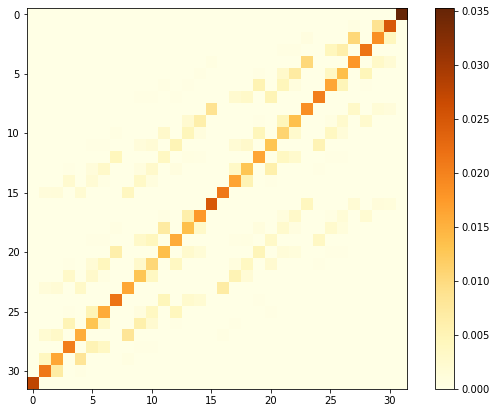

torch.Size([32, 32])


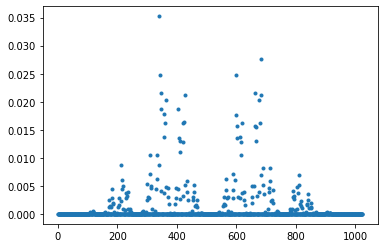

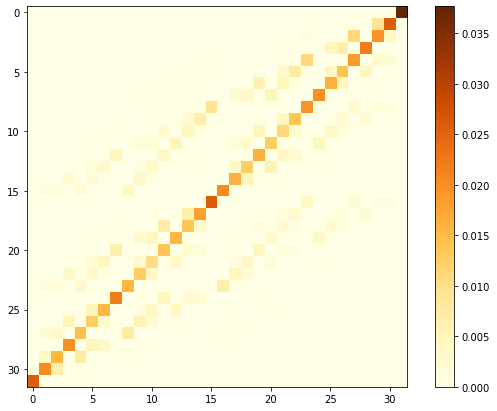

torch.Size([32, 32])


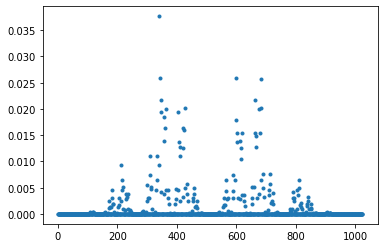

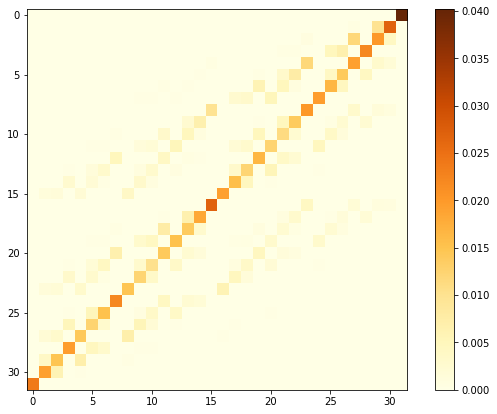

torch.Size([32, 32])


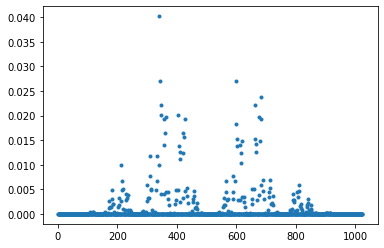

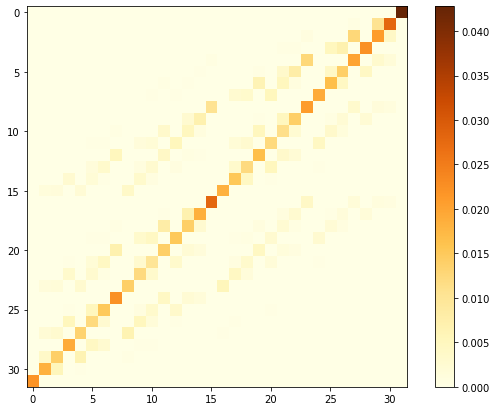

torch.Size([32, 32])


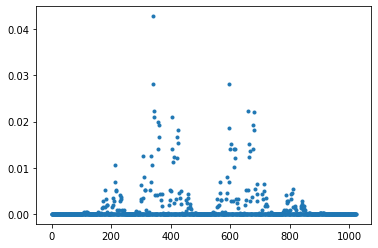

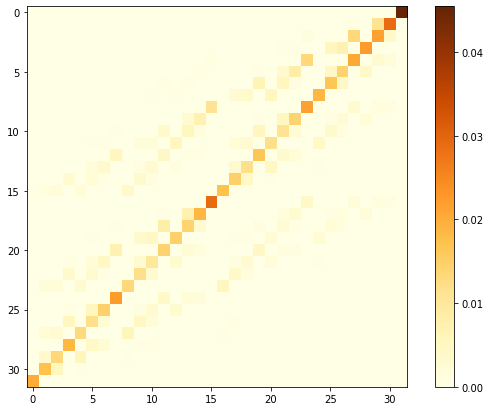

torch.Size([32, 32])


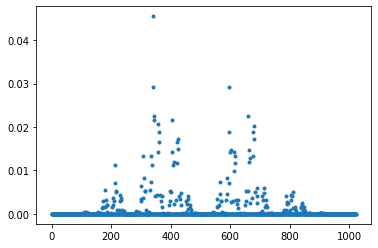

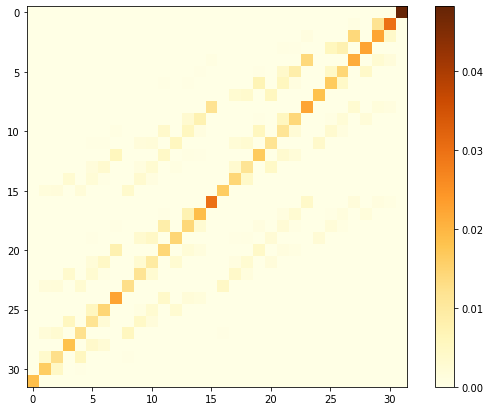

torch.Size([32, 32])


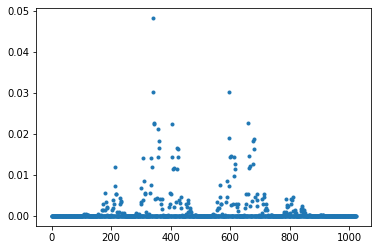

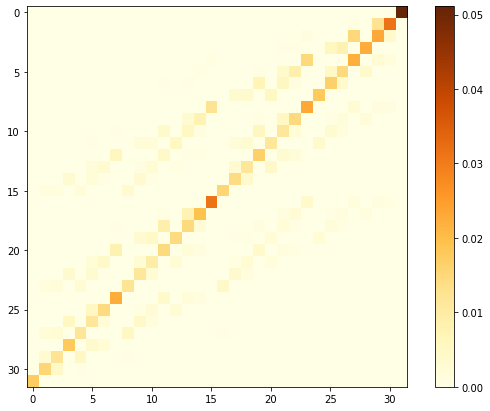

torch.Size([32, 32])


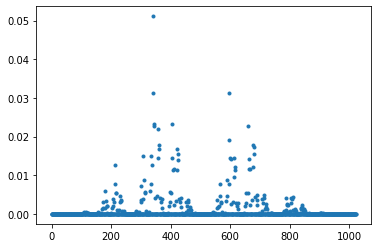

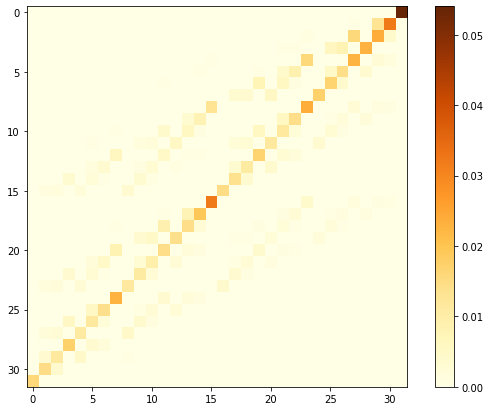

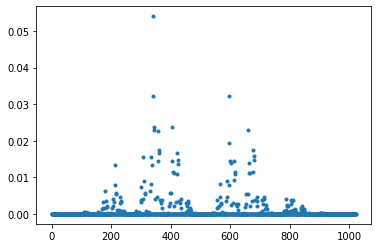

In [ ]:
res = torch.zeros(25, 2**5,2**5)
q = 0
basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
        #r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
      basis[r][i] = float(p[i])
    r -= 1

for k in np.arange(-100,100,10.7):
  m = k
  number_of_qubits = 10
  #H = Get_H(m, number_of_qubits)
  H = build_H_with_parameters.matrix(basis,m,1000,number_of_qubits)
  eig_values, eig_vector = torch.eig(H, eigenvectors = True)#[0][:, 0]
  eig_values = eig_values[:,0]
  #eig_vector = torch.eig(H, eigenvectors = True)[1]
  k = torch.min(eig_values,0)[1]
  R8 = eig_vector[:,k].reshape(2**number_of_qubits)
  #plt.plot(R8**2, '.')
  t = torch.arange(2**12)
  t = torch.arange(2**10)
  t = R8
  z = torch.zeros(math.ceil(t.shape[0]/4), 2,2)
  for i in range(math.ceil(t.shape[0]/4)):
    z[i] = t[4*i:4*i + 4].reshape(2,2)
  #print(z)
  e = torch.zeros(math.ceil(t.shape[0]/8), 2, 4)
  #print(e.shape)
  for i in range(math.ceil(t.shape[0]/8)):
    e[i] = torch.cat((z[2*i],z[2*i+1]), 1)
  #print(e)
  z = torch.zeros(math.ceil(t.shape[0]/16), 4, 4)
  for i in range(math.ceil(t.shape[0]/16)):
    z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
  #print(z, 'z')
  e = torch.zeros(math.ceil(t.shape[0]/32),4,8)
  for i in range(math.ceil(t.shape[0]/32)):
    e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
  #print(e)
  z = torch.zeros(math.ceil(t.shape[0]/64), 8, 8)
  for i in range(math.ceil(t.shape[0]/64)):
    z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
  #print(z, 'z')
  e = torch.zeros(math.ceil(t.shape[0]/128),8,16)
  for i in range(math.ceil(t.shape[0]/128)):
    e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
  #print(e)
  z = torch.zeros(math.ceil(t.shape[0]/256), 16, 16)
  for i in range(math.ceil(t.shape[0]/256)):
    z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
  #print(z, 'z')
  e = torch.zeros(math.ceil(t.shape[0]/512),16,32)
  for i in range(math.ceil(t.shape[0]/512)):
    e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
  print(res[q].shape)
  res[q] = torch.cat((e[0],e[1]) , 0)
  #print(res)
  
  plt.subplots(figsize=(10, 7))
  plt.imshow(res[q]**2,  cmap = 'YlOrBr')
  plt.colorbar()
  plt.show()
  plt.plot(R8**2,'.')
  q +=1

torch.Size([32, 32])


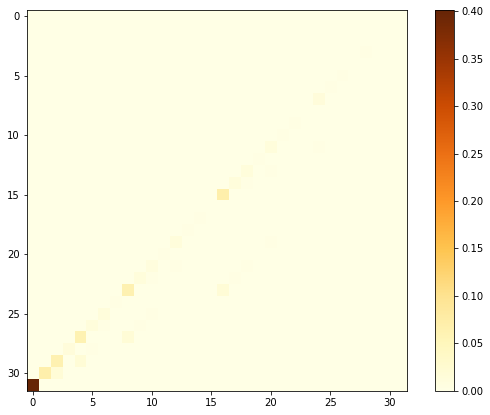

-1.4
torch.Size([32, 32])


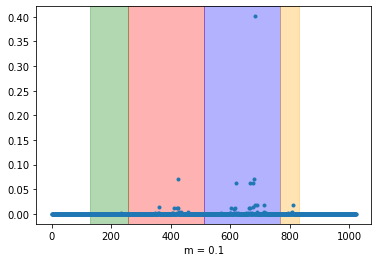

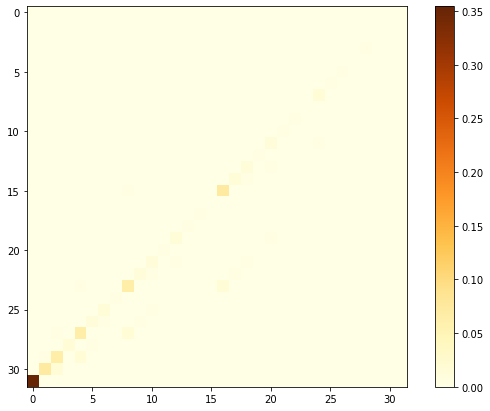

-1.2999999999999998
torch.Size([32, 32])


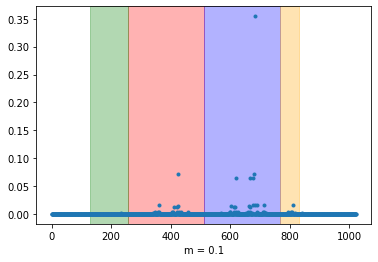

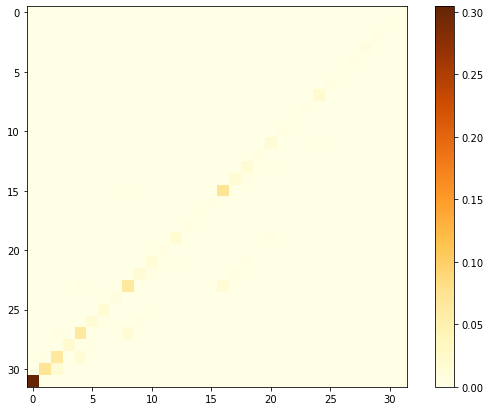

-1.1999999999999997
torch.Size([32, 32])


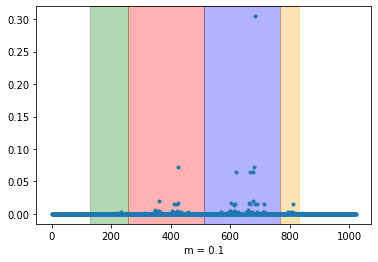

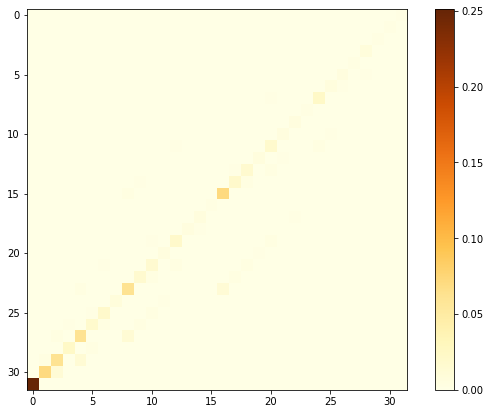

-1.0999999999999996
torch.Size([32, 32])


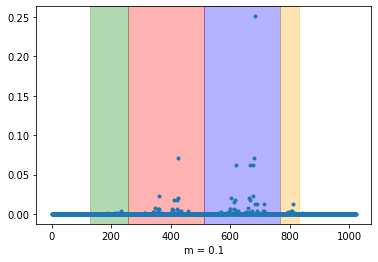

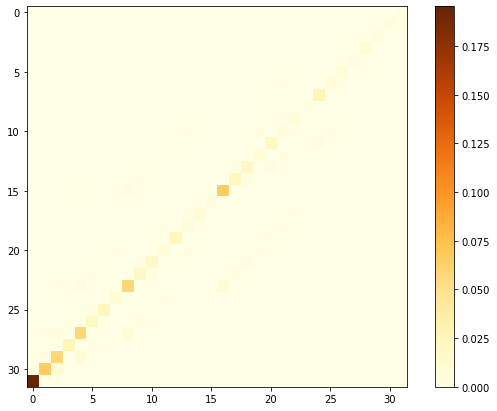

-0.9999999999999996
torch.Size([32, 32])


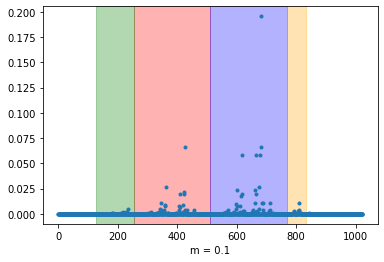

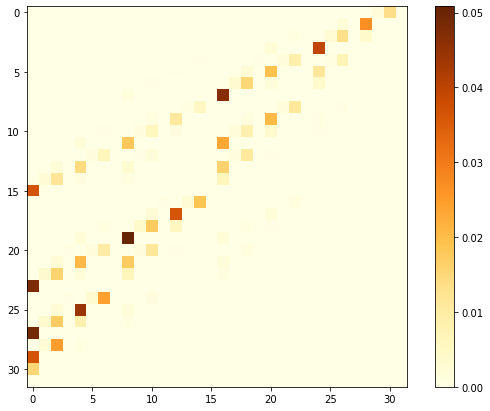

-0.8999999999999995
torch.Size([32, 32])


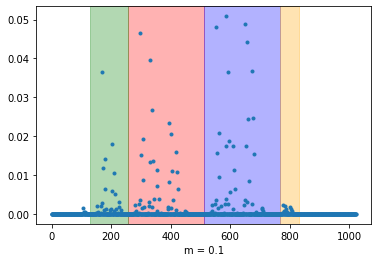

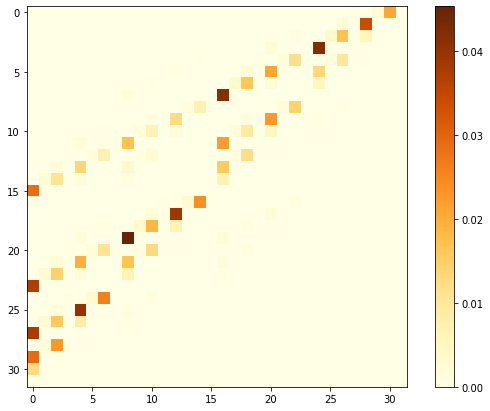

-0.7999999999999994
torch.Size([32, 32])


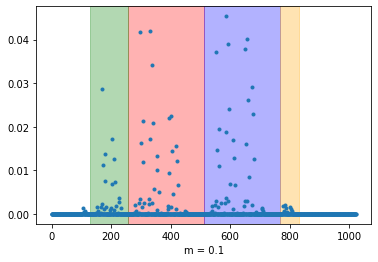

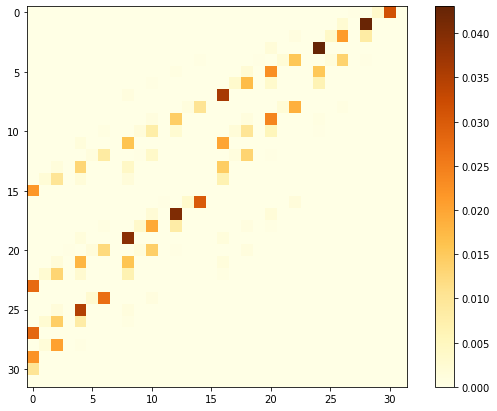

-0.6999999999999993
torch.Size([32, 32])


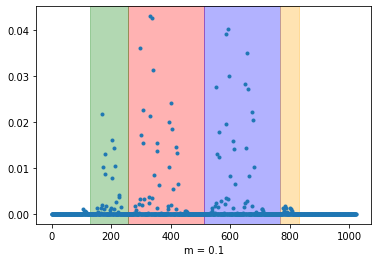

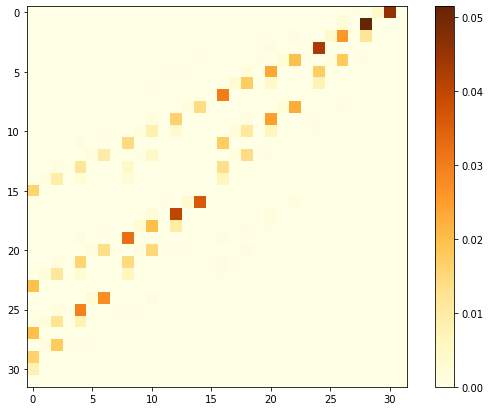

-0.5999999999999992
torch.Size([32, 32])


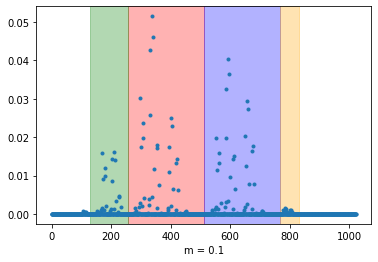

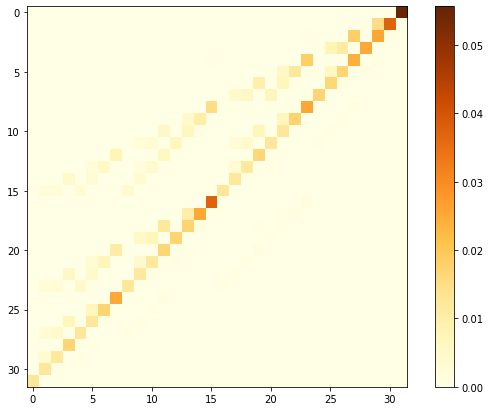

-0.4999999999999991
torch.Size([32, 32])


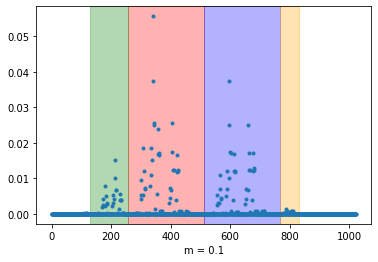

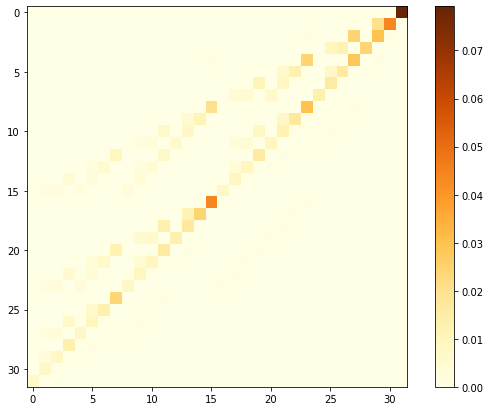

-0.399999999999999
torch.Size([32, 32])


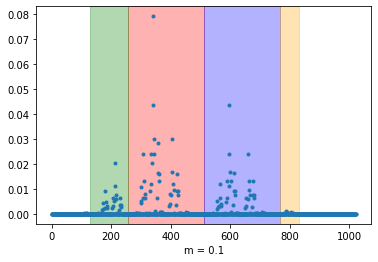

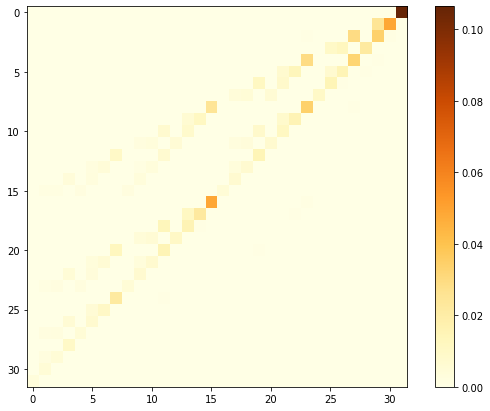

-0.29999999999999893
torch.Size([32, 32])


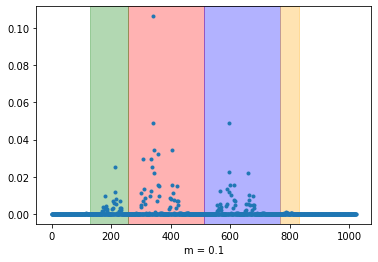

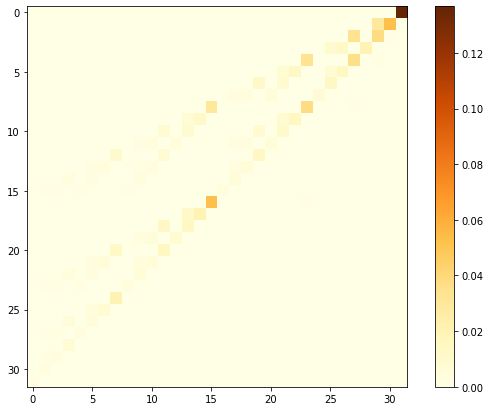

-0.19999999999999885
torch.Size([32, 32])


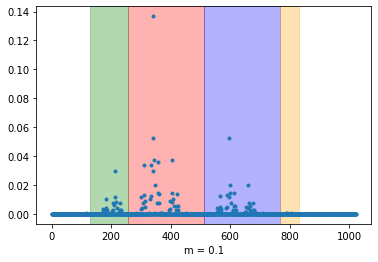

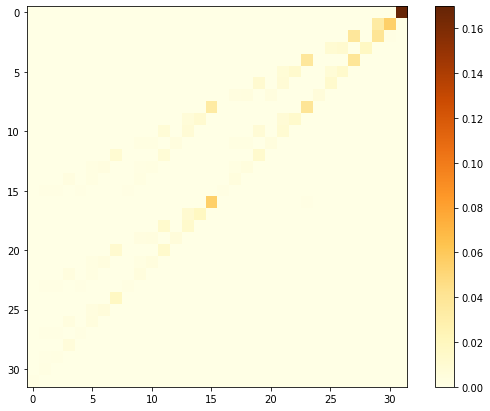

-0.09999999999999876
torch.Size([32, 32])


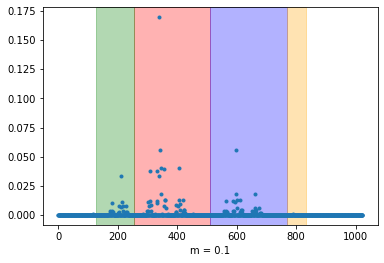

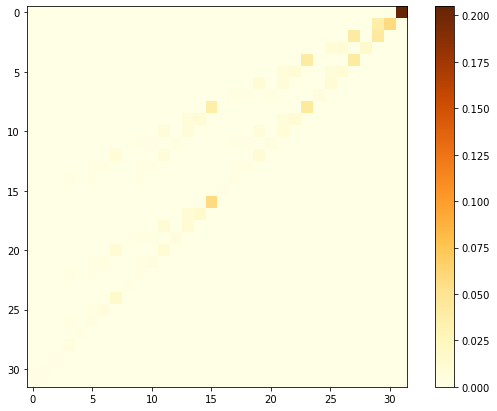

1.3322676295501878e-15
torch.Size([32, 32])


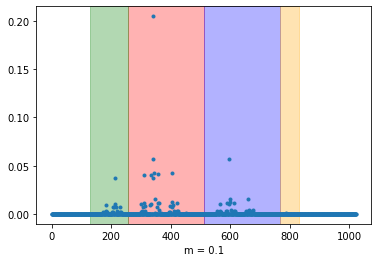

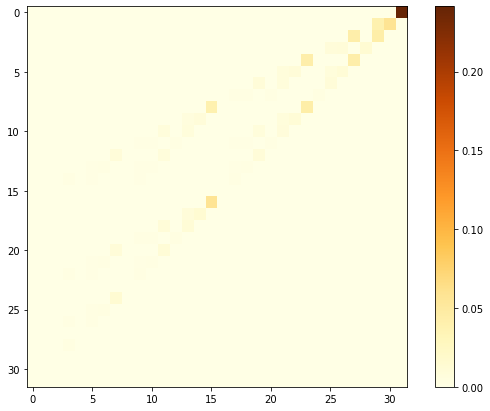

0.10000000000000142
torch.Size([32, 32])


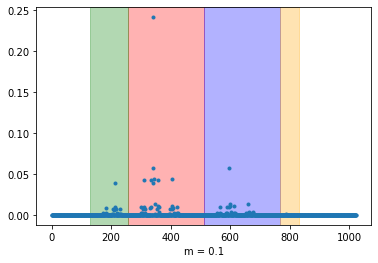

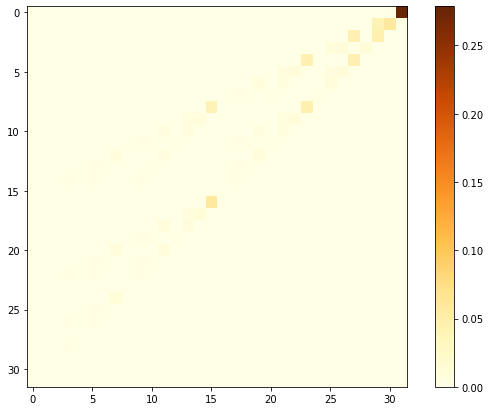

0.2000000000000015
torch.Size([32, 32])


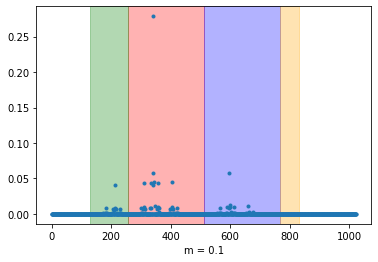

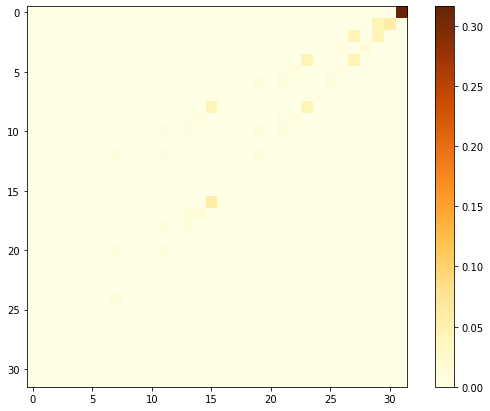

0.3000000000000016


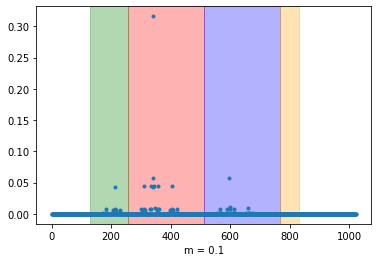

In [ ]:
res = torch.zeros(25, 2**5,2**5)
q = 0
basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
        #r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
      basis[r][i] = float(p[i])
    r -= 1

for k in np.arange(-1.4,0.4,0.1):
  m = k
  number_of_qubits = 10
  #H = Get_H(m, number_of_qubits)
  H = build_H_with_parameters.matrix(basis,m,1,number_of_qubits)
  eig_values, eig_vector = torch.eig(H, eigenvectors = True)#[0][:, 0]
  eig_values = eig_values[:,0]
  #eig_vector = torch.eig(H, eigenvectors = True)[1]
  k = torch.min(eig_values,0)[1]
  R8 = eig_vector[:,k].reshape(2**number_of_qubits)
  #plt.plot(R8**2, '.')
  t = torch.arange(2**12)
  t = torch.arange(2**10)
  t = R8
  z = torch.zeros(math.ceil(t.shape[0]/4), 2,2)
  for i in range(math.ceil(t.shape[0]/4)):
    z[i] = t[4*i:4*i + 4].reshape(2,2)
  #print(z)
  e = torch.zeros(math.ceil(t.shape[0]/8), 2, 4)
  #print(e.shape)
  for i in range(math.ceil(t.shape[0]/8)):
    e[i] = torch.cat((z[2*i],z[2*i+1]), 1)
  #print(e)
  z = torch.zeros(math.ceil(t.shape[0]/16), 4, 4)
  for i in range(math.ceil(t.shape[0]/16)):
    z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
  #print(z, 'z')
  e = torch.zeros(math.ceil(t.shape[0]/32),4,8)
  for i in range(math.ceil(t.shape[0]/32)):
    e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
  #print(e)
  z = torch.zeros(math.ceil(t.shape[0]/64), 8, 8)
  for i in range(math.ceil(t.shape[0]/64)):
    z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
  #print(z, 'z')
  e = torch.zeros(math.ceil(t.shape[0]/128),8,16)
  for i in range(math.ceil(t.shape[0]/128)):
    e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
  #print(e)
  z = torch.zeros(math.ceil(t.shape[0]/256), 16, 16)
  for i in range(math.ceil(t.shape[0]/256)):
    z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
  #print(z, 'z')
  e = torch.zeros(math.ceil(t.shape[0]/512),16,32)
  for i in range(math.ceil(t.shape[0]/512)):
    e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
  print(res[q].shape)
  res[q] = torch.cat((e[0],e[1]) , 0)
  #print(res)
  
  plt.subplots(figsize=(10, 7))
  plt.imshow(res[q]**2,  cmap = 'YlOrBr')
  plt.colorbar()
  plt.show()
  fig, ax = plt.subplots()
  ax.plot(R8**2, '.')
  ax.set_xlabel('m = 0.1')
  print(m)
  plt.axvspan(256, 512, color='red', alpha=0.3)
  plt.axvspan(512, 512 + 256, color='blue', alpha=0.3)
  plt.axvspan(128, 256, color='green', alpha=0.3)
  plt.axvspan(512+256, 512 + 256 + 64, color='orange', alpha=0.3)
  q +=1

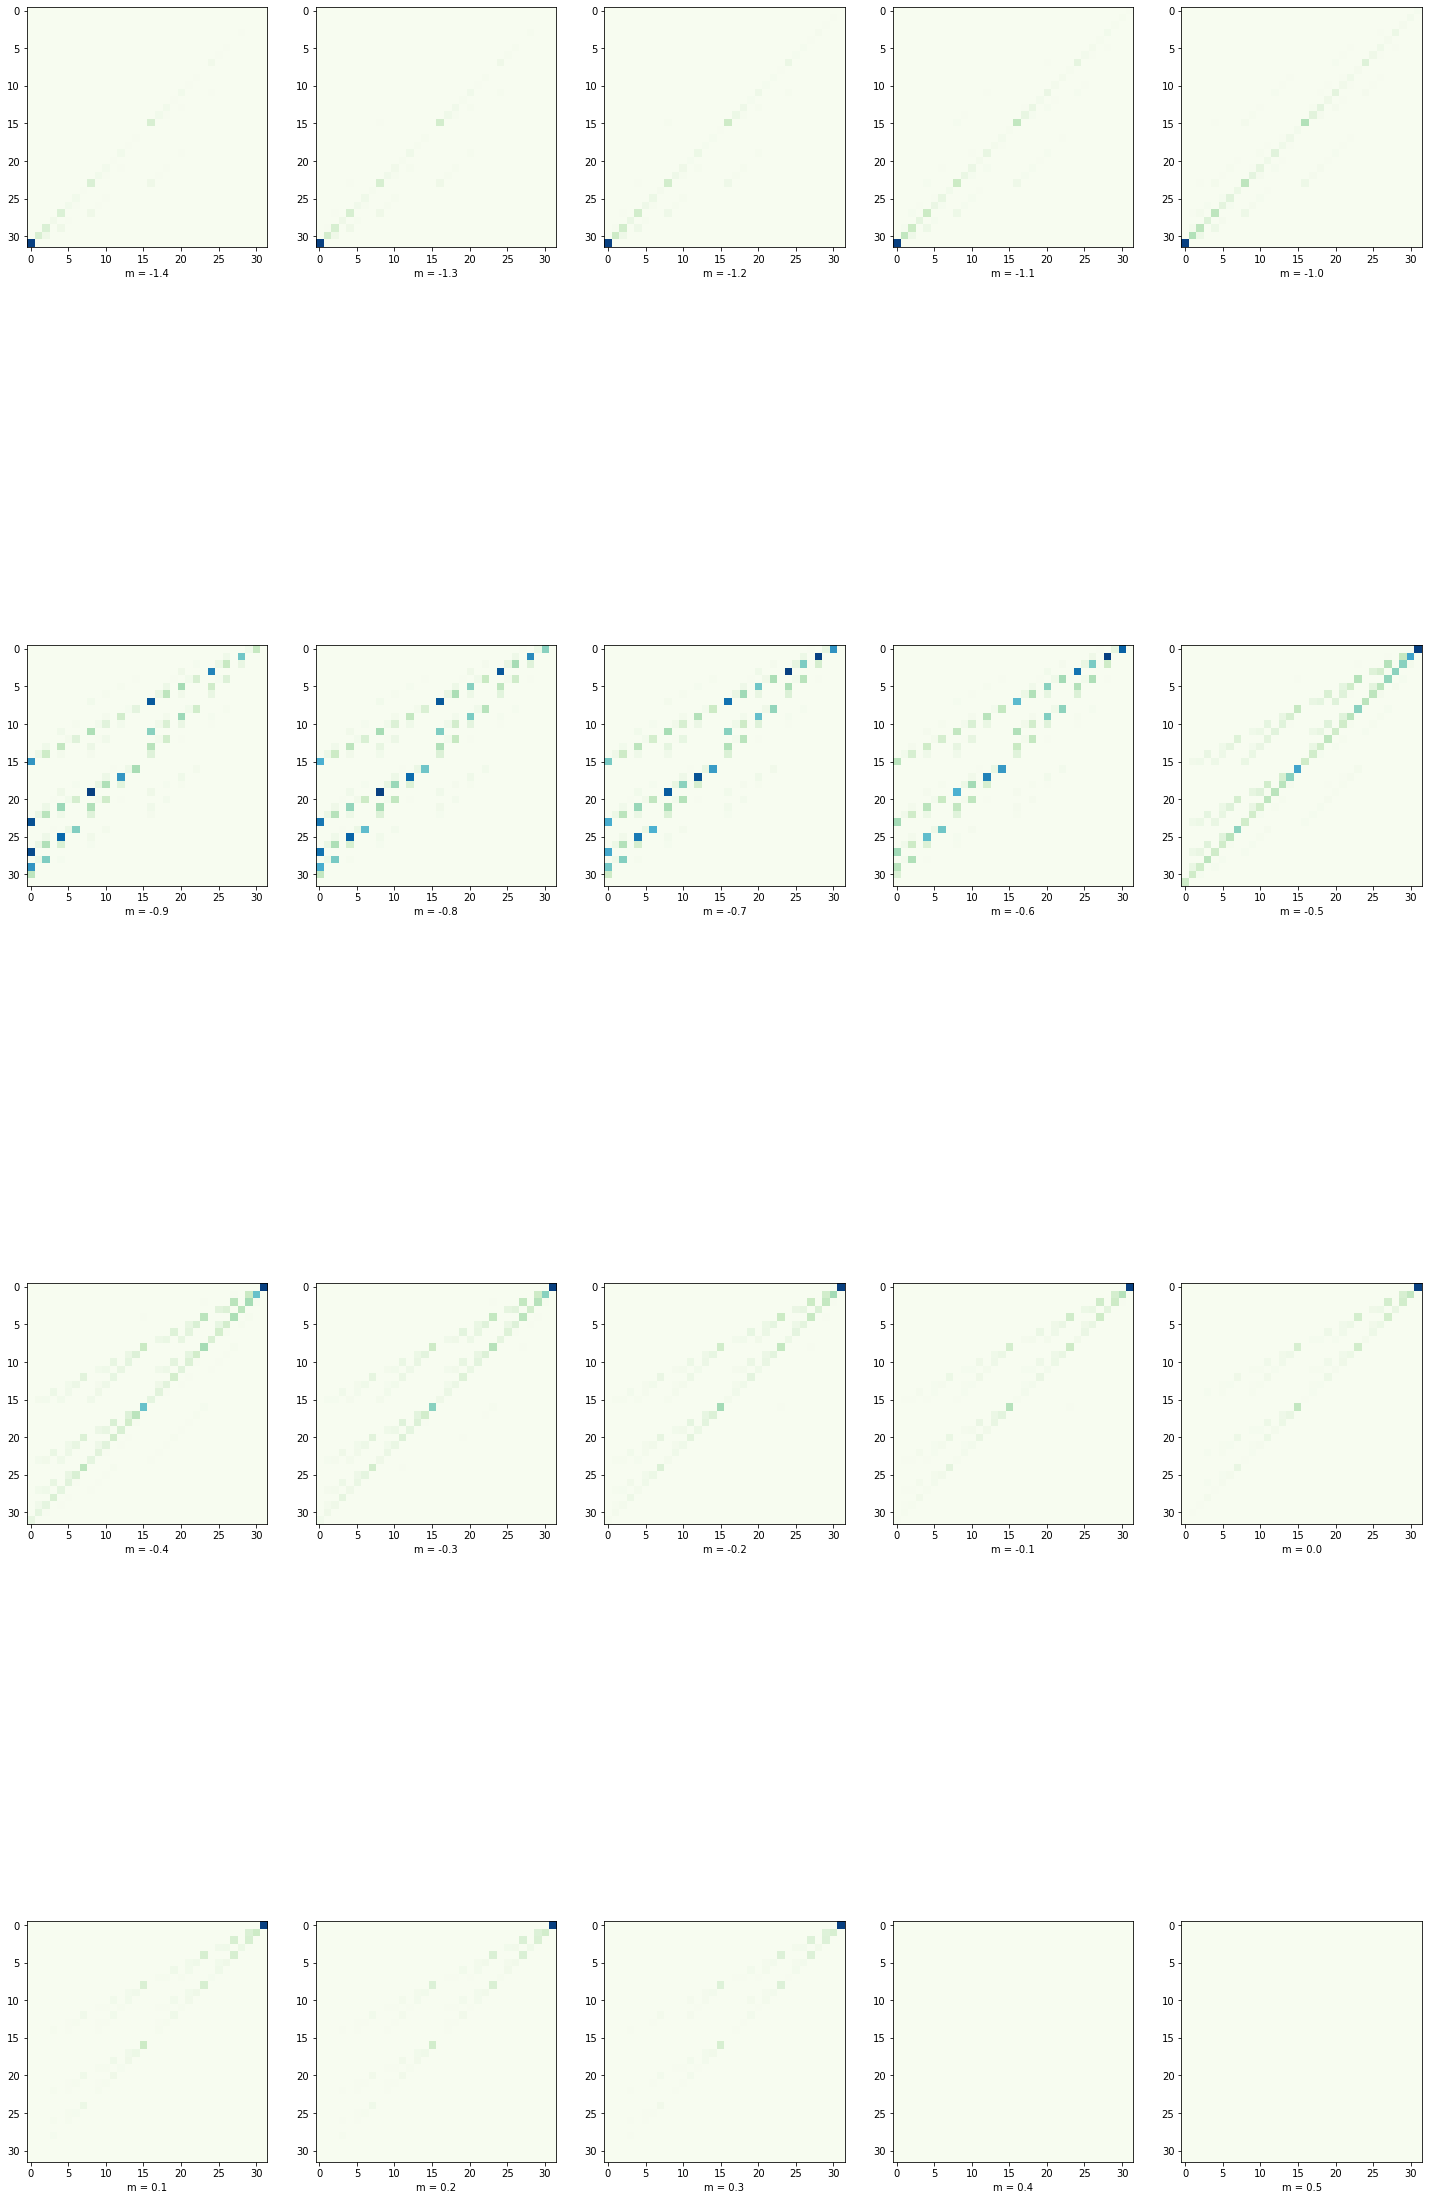

In [ ]:
k = 0
m = -1.4
fig, axs = plt.subplots(4, 5, figsize=(25, 45))
for i in range(4):
  for j in range(5):

    axs[i,j].imshow(res[k + j]**2,  cmap = 'GnBu')
    #axs[i,j].colorbar()
    axs[i,j].set_xlabel('m = {}'.format(round(m, 1)))
    #axs[i, j].scatter(x, R[k + j]**2)
    m += 0.1
  k += 5
#x = 100
plt.show()

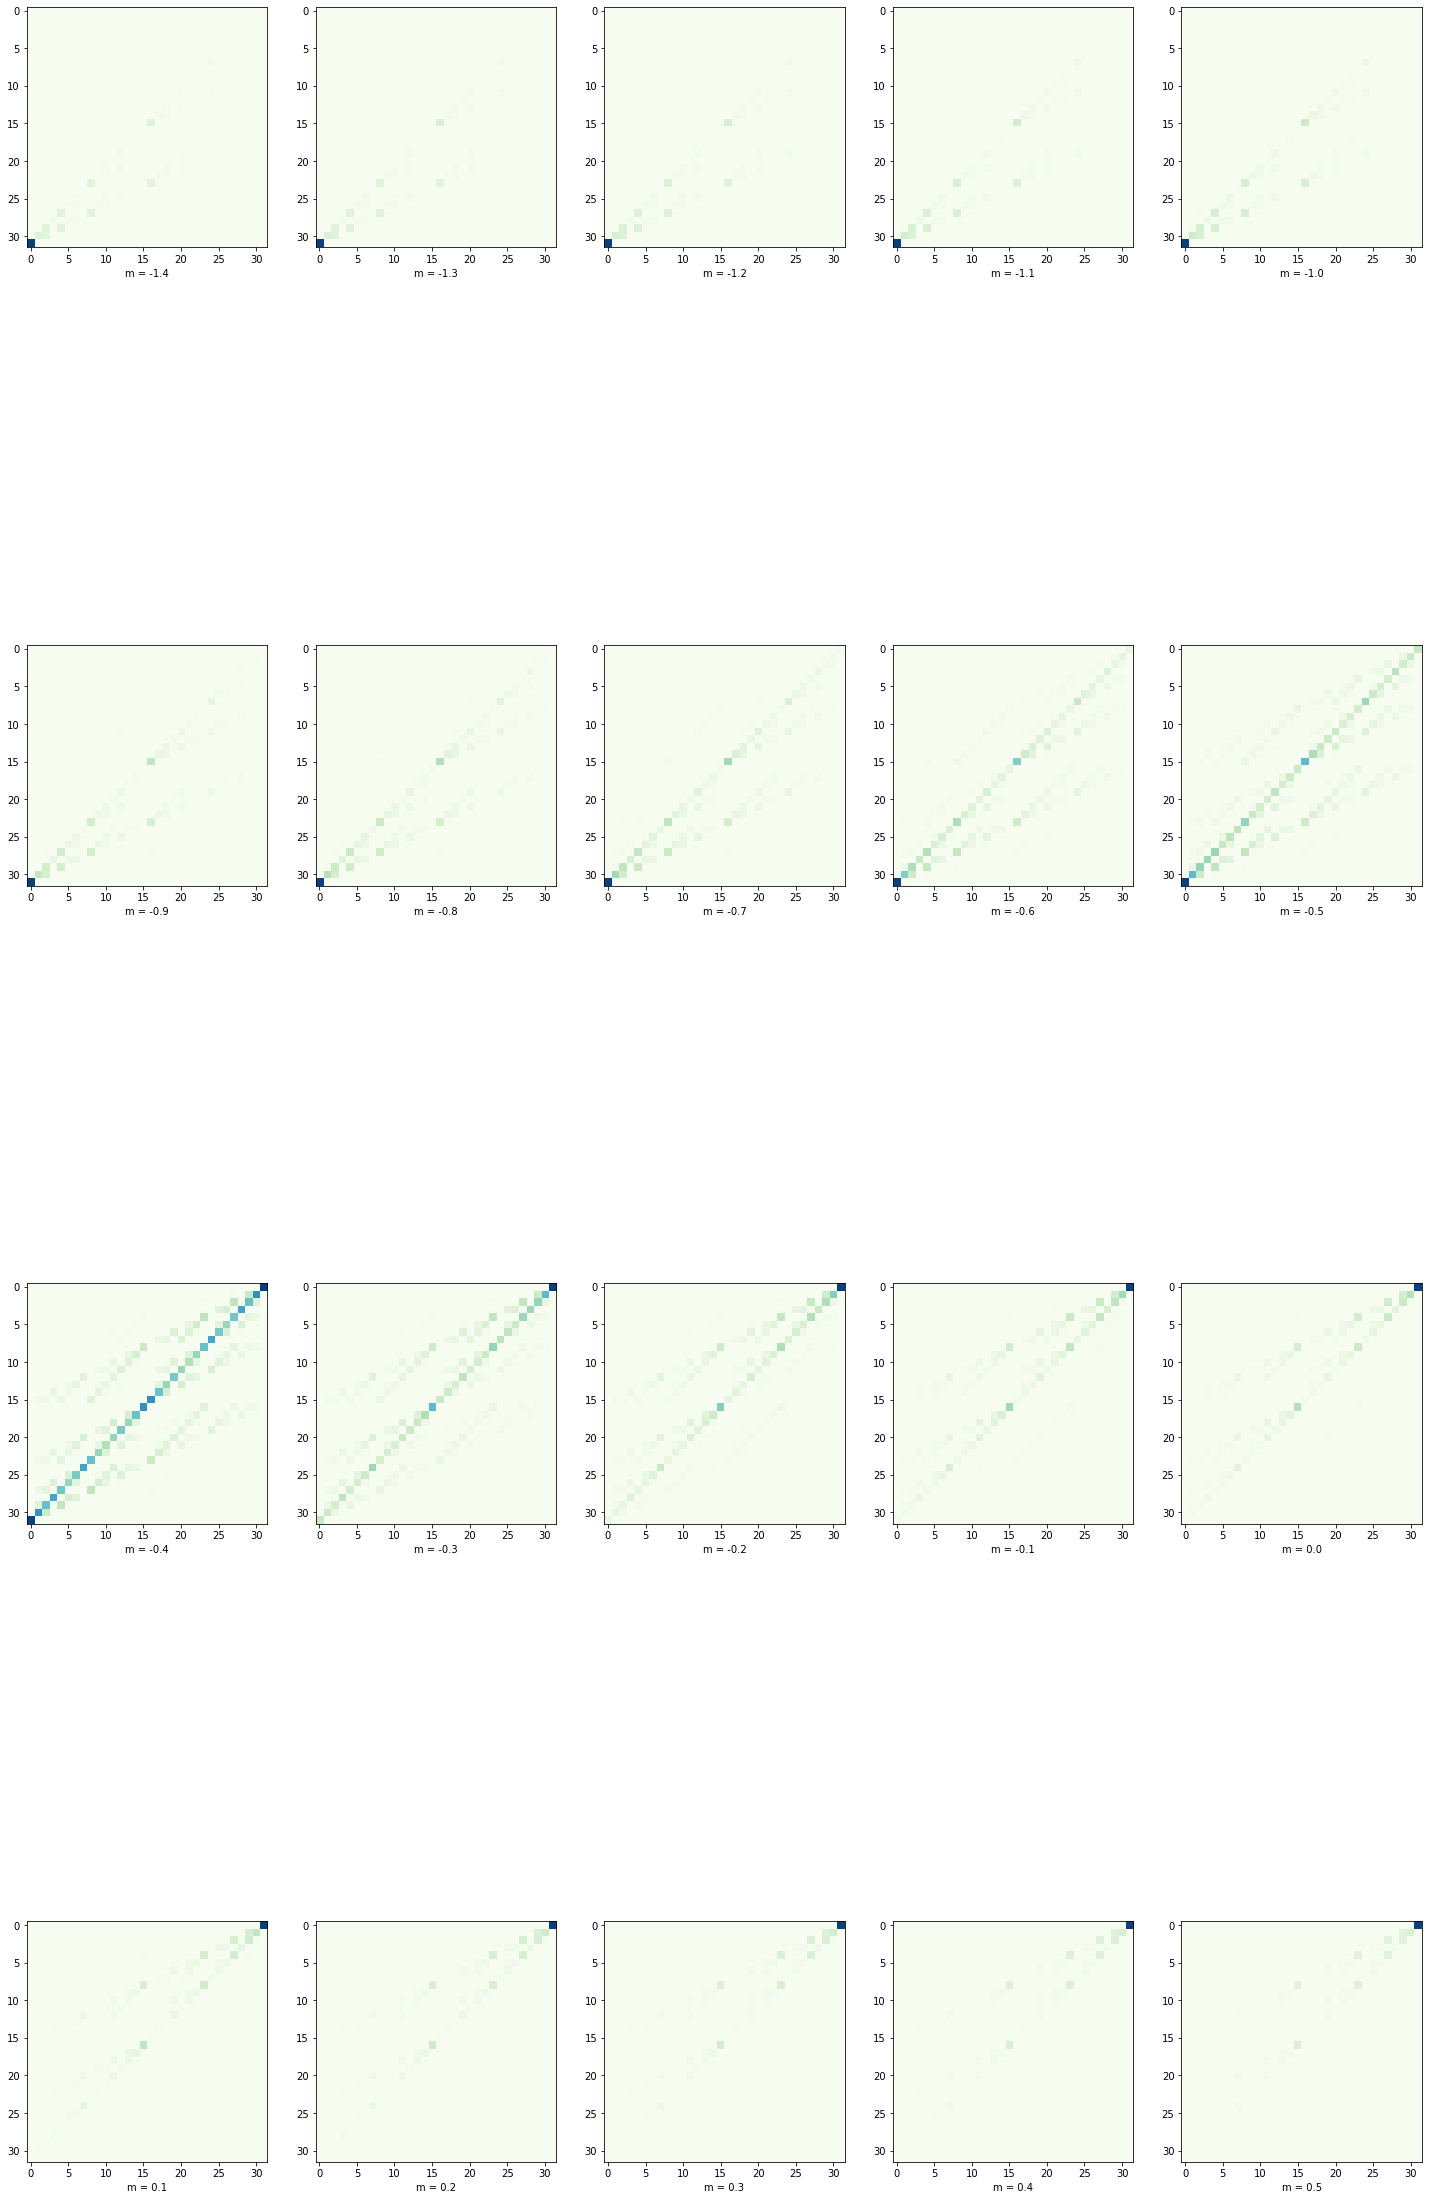

In [ ]:
k = 0
m = -1.4
fig, axs = plt.subplots(4, 5, figsize=(25, 45))
for i in range(4):
  for j in range(5):

    axs[i,j].imshow(res[k + j]**2,  cmap = 'GnBu')
    #axs[i,j].colorbar()
    axs[i,j].set_xlabel('m = {}'.format(round(m, 1)))
    #axs[i, j].scatter(x, R[k + j]**2)
    m += 0.1
  k += 5
#x = 100
plt.show()

tensor([[170],
        [172],
        [178],
        [202],
        [210],
        [212],
        [298],
        [300],
        [306],
        [308],
        [330],
        [332],
        [338],
        [340],
        [354],
        [356],
        [394],
        [396],
        [402],
        [404],
        [418],
        [420],
        [554],
        [556],
        [562],
        [564],
        [586],
        [588],
        [594],
        [596],
        [610],
        [612],
        [650],
        [652],
        [658],
        [660],
        [674],
        [676],
        [680]])


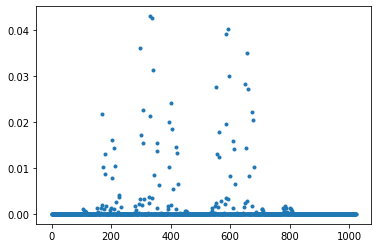

In [ ]:
m = -0.7
a = 341
number_of_qubits = 10
H = Get_H(m, number_of_qubits)
eig_values, eig_vector = torch.eig(H, eigenvectors = True)#[0][:, 0]
eig_values = eig_values[:,0]
#eig_vector = torch.eig(H, eigenvectors = True)[1]
k = torch.min(eig_values,0)[1]
R8 = eig_vector[:,k].reshape(2**number_of_qubits)
plt.plot(R8**2, '.')
print((R8**2 > 0.01).nonzero())

tensor([[ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0., -2.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  2.,  ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.,  ..., -2.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  2.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.]])


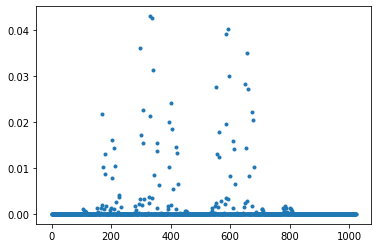

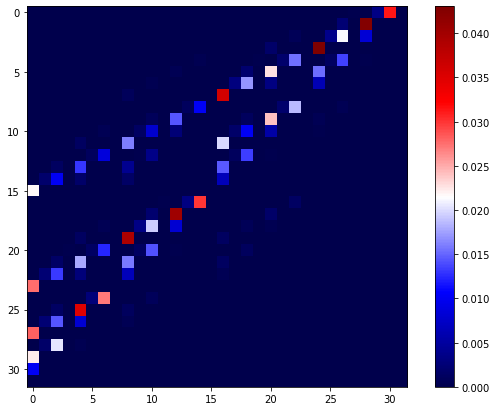

In [ ]:
m = -0.7
number_of_qubits = 10
H = Get_H(m, number_of_qubits)
eig_values, eig_vector = torch.eig(H, eigenvectors = True)#[0][:, 0]
eig_values = eig_values[:,0]
#eig_vector = torch.eig(H, eigenvectors = True)[1]
k = torch.min(eig_values,0)[1]
R8 = eig_vector[:,k].reshape(2**number_of_qubits)
plt.plot(R8**2, '.')
t = torch.arange(2**12)
t = torch.arange(2**10)
t = R8
z = torch.zeros(math.ceil(t.shape[0]/4), 2,2)
for i in range(math.ceil(t.shape[0]/4)):
  z[i] = t[4*i:4*i + 4].reshape(2,2)
#print(z)
e = torch.zeros(math.ceil(t.shape[0]/8), 2, 4)
#print(e.shape)
for i in range(math.ceil(t.shape[0]/8)):
  e[i] = torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
z = torch.zeros(math.ceil(t.shape[0]/16), 4, 4)
for i in range(math.ceil(t.shape[0]/16)):
  z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
#print(z, 'z')
e = torch.zeros(math.ceil(t.shape[0]/32),4,8)
for i in range(math.ceil(t.shape[0]/32)):
  e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
z = torch.zeros(math.ceil(t.shape[0]/64), 8, 8)
for i in range(math.ceil(t.shape[0]/64)):
  z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
#print(z, 'z')
e = torch.zeros(math.ceil(t.shape[0]/128),8,16)
for i in range(math.ceil(t.shape[0]/128)):
  e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
z = torch.zeros(math.ceil(t.shape[0]/256), 16, 16)
for i in range(math.ceil(t.shape[0]/256)):
  z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
#print(z, 'z')
e = torch.zeros(math.ceil(t.shape[0]/512),16,32)
for i in range(math.ceil(t.shape[0]/512)):
  e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
res = torch.cat((e[0],e[1]) , 0)
#print(res)
plt.subplots(figsize=(10, 7))
plt.imshow(res**2,  cmap = 'seismic')
plt.colorbar()

tensor([[ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0., -2.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  2.,  ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.,  ..., -2.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  2.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.]])
torch.Size([1024])


IndexError: ignored

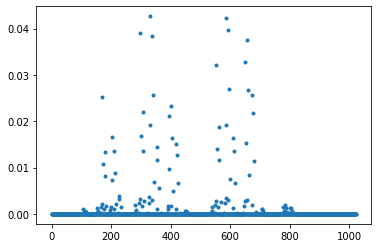

In [ ]:
m = -0.75
number_of_qubits = 12
H = Get_H(m, number_of_qubits)
eig_values, eig_vector = torch.eig(H, eigenvectors = True)#[0][:, 0]
eig_values = eig_values[:,0]
#eig_vector = torch.eig(H, eigenvectors = True)[1]
k = torch.min(eig_values,0)[1]
R8 = eig_vector[:,k].reshape(2**number_of_qubits)
plt.plot(R8**2, '.')
t = torch.arange(2**12)
t = R8
print(t.shape)
z = torch.zeros(math.ceil(t.shape[0]/4), 2,2)
for i in range(math.ceil(t.shape[0]/4)):
  z[i] = t[4*i:4*i + 4].reshape(2,2)
#print(z)
e = torch.zeros(math.ceil(t.shape[0]/8), 2, 4)
#print(e.shape)
for i in range(math.ceil(t.shape[0]/8)):
  e[i] = torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
z = torch.zeros(math.ceil(t.shape[0]/16), 4, 4)
for i in range(math.ceil(t.shape[0]/16)):
  z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
#print(z, 'z')
e = torch.zeros(math.ceil(t.shape[0]/32),4,8)
for i in range(math.ceil(t.shape[0]/32)):
  e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
z = torch.zeros(math.ceil(t.shape[0]/64), 8, 8)
for i in range(math.ceil(t.shape[0]/64)):
  z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
#print(z, 'z')
e = torch.zeros(math.ceil(t.shape[0]/128),8,16)
for i in range(math.ceil(t.shape[0]/128)):
  e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
z = torch.zeros(math.ceil(t.shape[0]/256), 16, 16)
for i in range(math.ceil(t.shape[0]/256)):
  z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
#print(z, 'z')
e = torch.zeros(math.ceil(t.shape[0]/512),16,32)
for i in range(math.ceil(t.shape[0]/512)):
  e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
z = torch.zeros(math.ceil(t.shape[0]/1024), 32, 32)
for i in range(math.ceil(t.shape[0]/1024)):
  z[i] = torch.cat((e[2*i],e[2*i+1]), 0)
#print(z, 'z')
e = torch.zeros(math.ceil(t.shape[0]/2048),32,64)
for i in range(math.ceil(t.shape[0]/2048)):
  e[i] =torch.cat((z[2*i],z[2*i+1]), 1)
#print(e)
res = torch.cat((e[0],e[1]) , 0)
#print(res)
plt.subplots(figsize=(10, 7))
plt.imshow(res**2, cmap = 'seismic')
plt.colorbar()

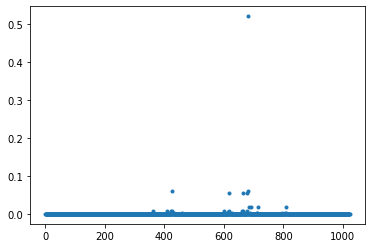

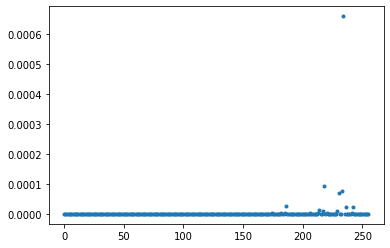

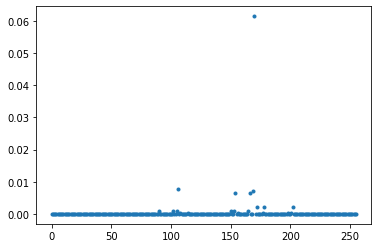

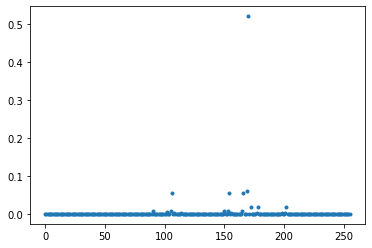

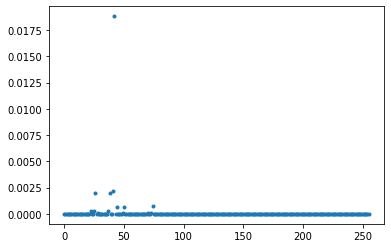

tensor(-0.9999)


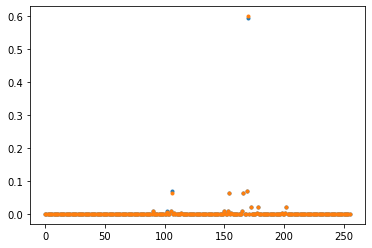

In [ ]:
plt.plot(R**2,'.')
plt.show()
ll = R[0:256]
l = R[256:512]
r = R[512:768]
rr = R[768:1024]
plt.plot(ll**2,'.')
plt.show()
plt.plot(l**2,'.')
plt.show()
plt.plot(r**2,'.')
plt.show()
plt.plot(rr**2,'.')
plt.show()
plt.plot(R8**2,'.')
plt.plot((r/r.norm())**2,'.')
print(R8.dot(r/r.norm()))

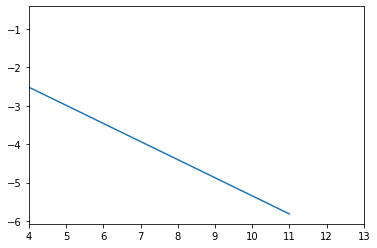

[tensor(-0.6662), tensor(-1.0862), tensor(-1.5791), tensor(-2.0422), tensor(-2.5172), tensor(-2.9873), tensor(-3.4595), tensor(-3.9308), tensor(-4.4024), tensor(-4.8740), tensor(-5.3456), tensor(-5.8170)]


In [ ]:
np.save('Gr_st', Gr_st)
plt.plot(Gr_st)
plt.xlim(4,13)
plt.show()
print(Gr_st)

In [ ]:
for i in range(4,11):
  H = Get_H(0.1, i)
  plt.subplots(figsize=(10, 7))
  plt.imshow(H,cmap = 'seismic')
  plt.colorbar()
  


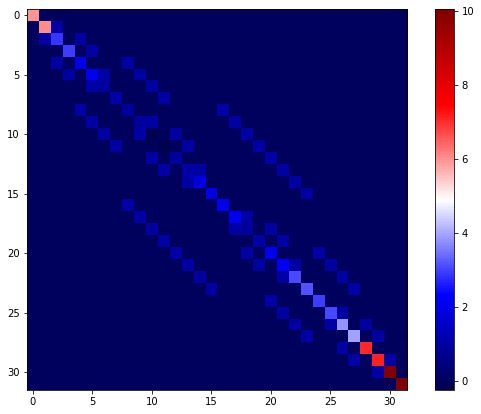

In [ ]:
H = Get_H(0.1, 5)
plt.subplots(figsize=(10, 7))
plt.imshow(H,cmap = 'seismic')
plt.colorbar()
plt.savefig('pic.pdf',dpi=500)

In [ ]:
def matrix_element_iter_new(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    C = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1).to(device)
    
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2    

    #print(coef, 'coef')
    #print(batch_new[j]*coef, 't')

    C[j,j] = -(batch_new[j]*coef).sum(dim = 1) ## почему -?
    #print(C[j,j])
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2).to(device)
    #print(coef_2, 'c2')

    for i in range(0,number_of_qubits-1):
        s = torch.zeros(batch_size).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m - 1, coef_2[m-1], 'm')
            s += coef_2[m - 1]*batch_new[:,m]
            #print(s,'s')
        #print(s)    
        C[j,j] += batch_new[j,i]*s[j]
    #print(C[j,j])   
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I  
    k = torch.arange(C.shape[0])  
    #print(One[0,0]/4, 'One')
    #print(C[k,k]/4, 'C')
    return (C + One)/4
                
            
def matrix_element_xy(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    
    place = torch.zeros(number_of_qubits -1,2)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][0]= i
        place[i][1] = i+1
    outt = torch.arange(batch_size)
    for i in outt:
        for j in outt:
            true = (torch.nonzero(batch_new[i] != batch_new[j])).reshape(-1)
            if (true.shape[0] == 2) and ((true == place).prod(dim = 1).sum()):
                C[i,j] = 1 -batch_new[i,true[0]]*batch_new[i,true[1]]
    return C/2

def matrix_element_m(batch):

    batch_new = torch.clone(batch)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    
    t = torch.arange(0,number_of_qubits,1).to(device)
    
    batch_new[:,t] *= (-1)**(t+1)
    
    M = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1)
    M[j,j] = -batch_new.sum(dim = 1)
        #N+= M
    return m/2*M

def matrix_element_xy_new_7(batch):
    batch_new = torch.clone(batch)
    #print(batch_new.device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    res = batch_new.unsqueeze(1) != batch_new
    
    place = torch.zeros(number_of_qubits -1,number_of_qubits).to(device)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][i]= 1
        place[i][i+1] = 1
        true = torch.nonzero((res == place[i]).prod(dim = 2)==1)
        ress = batch_new[true[:,0],i]*batch_new[true[:,0],i+1]
        C[true[:,0], true[:,1]] = 1 - ress
    return C/2

def matrix(batch):               
    return   matrix_element_m(batch) + matrix_element_iter_new(batch) #+ matrix_element_xy_new_7(batch)# +

4
torch.Size([6])
tensor([ 1.0000, -0.2000,  1.0000,  1.0000,  2.2000,  3.0000]) diagonal M
5
torch.Size([10])
tensor([ 2.9500,  2.1500,  0.9500,  0.9500, -0.2500,  0.9500,  2.1500,  0.9500,
         2.1500,  2.9500]) diagonal M
6
torch.Size([20])
tensor([ 2.9000,  2.1000,  0.9000,  2.1000,  0.9000, -0.3000,  0.9000,  0.9000,
         2.1000,  2.9000,  2.1000,  0.9000,  2.1000,  2.1000,  3.3000,  4.1000,
         2.9000,  4.1000,  4.9000,  8.1000]) diagonal M
7
torch.Size([35])
tensor([ 8.0500,  4.8500,  4.0500,  2.8500,  4.0500,  3.2500,  2.0500,  2.0500,
         0.8500,  2.0500,  2.8500,  2.0500,  0.8500,  0.8500, -0.3500,  0.8500,
         2.0500,  0.8500,  2.0500,  2.8500,  4.0500,  3.2500,  2.0500,  2.0500,
         0.8500,  2.0500,  3.2500,  2.0500,  3.2500,  4.0500,  4.0500,  2.8500,
         4.0500,  4.8500,  8.0500]) diagonal M
8
torch.Size([70])
tensor([ 8.0000,  4.8000,  4.0000,  2.8000,  4.0000,  4.0000,  3.2000,  2.0000,
         3.2000,  2.0000,  0.8000,  2.0000,  2.0000

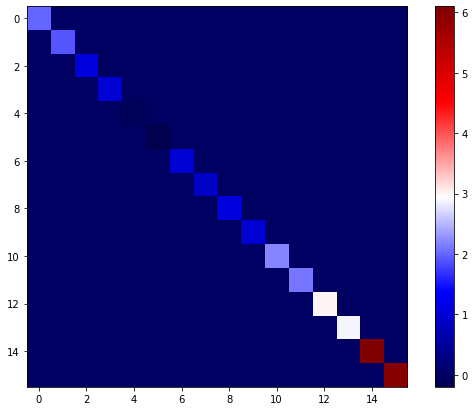

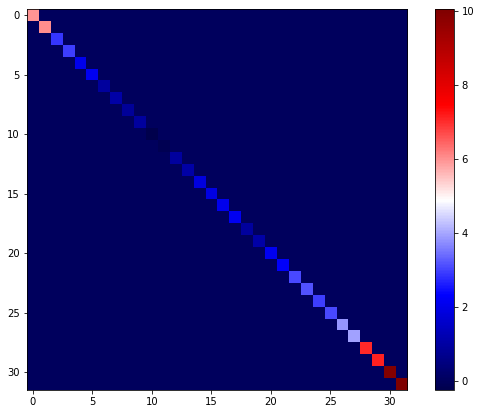

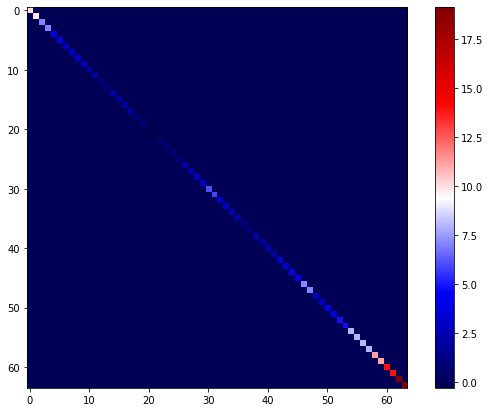

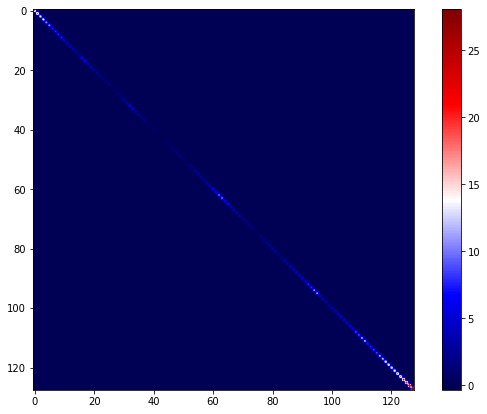

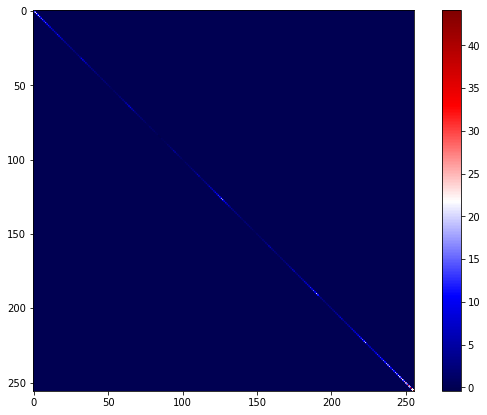

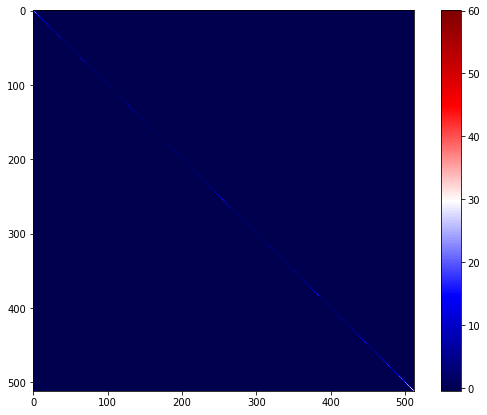

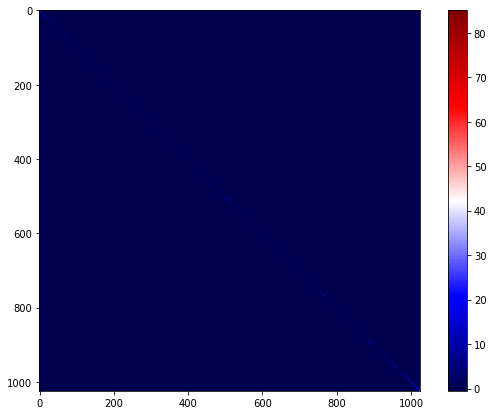

In [ ]:
for j in range(4,11,1):
  number_of_qubits = j
  basis = torch.zeros(2**number_of_qubits,number_of_qubits)
  r = 2**number_of_qubits - 1
      #r = 0
  for p in product('10', repeat= number_of_qubits):
      for i in range(number_of_qubits):
          basis[r][i] = float(p[i])
      r -= 1
  sum_spin = math.ceil((number_of_qubits - 1) / 2 )
  #print(sum_spin)
  e = torch.tensor([10,21,42,85,170,341,682])
  good_vectors = basis.sum(dim = 1)
  good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
  #print(good_vectors)
  sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
  i = torch.arange(0, good_vectors.shape[0], 1)
  #print(i.shape, good_vectors.shape)
  sub_batch[i, :] = basis[good_vectors, :]
  good_batch = sub_batch
  #H = Get_H(0.1, j)
  m = 0.1
  #r = M.shape[0]
  batch = torch.clone(basis)
  print(number_of_qubits)
  M1 = matrix(batch)
  M = matrix(good_batch.to(device))
  #print((M == M1).prod(),'ravno')
  i = torch.arange(0,M.shape[0],1)
  print(i.shape)
  k = torch.arange(0,M1.shape[0],1)
  #i = torch.arange(r,M.shape[0],1)
  #print(M1[k,k],'diagonal M1')
  print(M[i,i], 'diagonal M')
  #print(M1[e[j-4],e[j-4]], 'here')

  #print(batch[0:M1.shape[0]], 'batch')
  #print(good_batch[0:M.shape[0]], 'batch')
  
  plt.subplots(figsize=(10, 7))
  plt.imshow(M.cpu(),cmap = 'seismic')
  plt.imshow(M1,cmap = 'seismic')
  plt.colorbar()

tensor([[ 0.,  0.,  0.,  0.],
        [ 0., -2.,  0.,  0.],
        [ 0.,  0.,  2.,  0.],
        [ 0.,  0.,  0.,  0.]])
tensor([[-1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., -3.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., -1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  3.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]])
tensor([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0., -2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.],
        [ 0.,  0.,  0.,  0., -2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
   

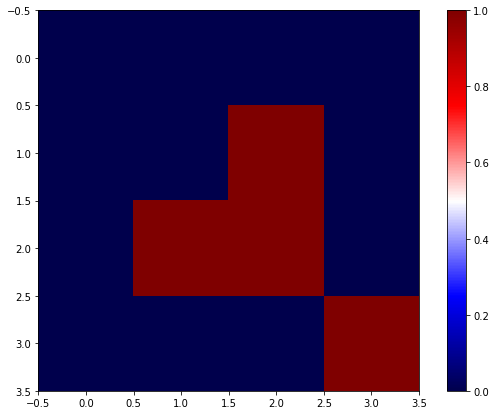

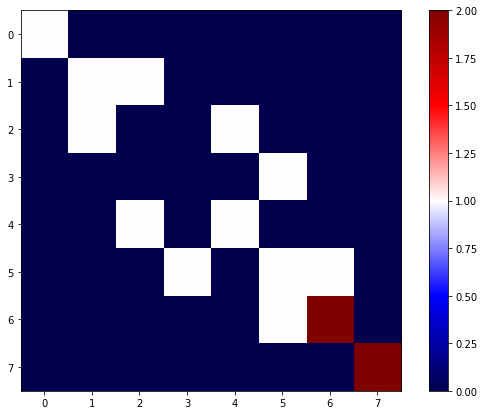

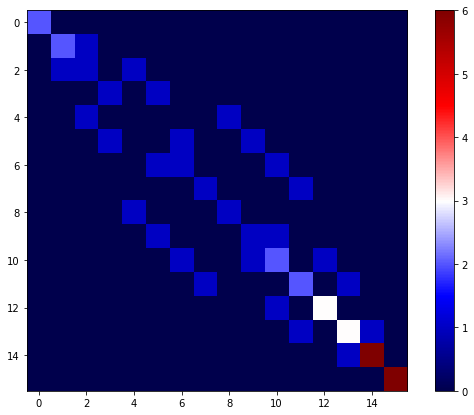

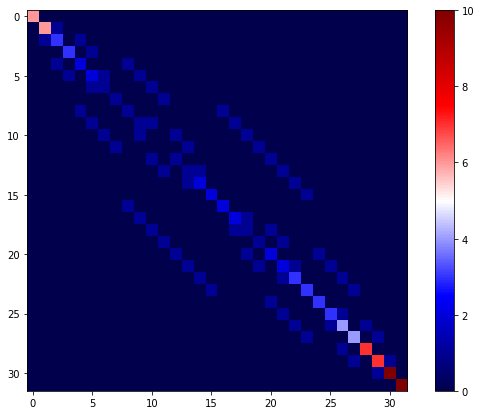

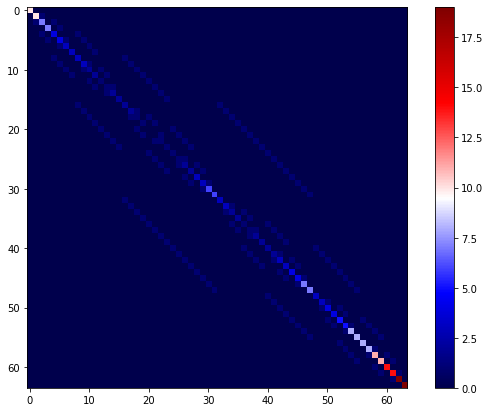

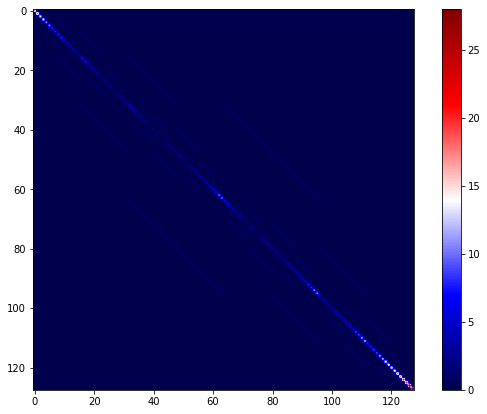

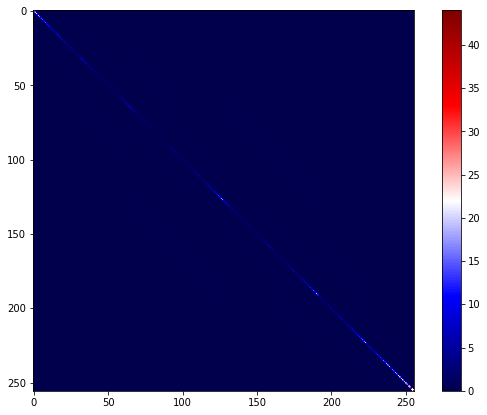

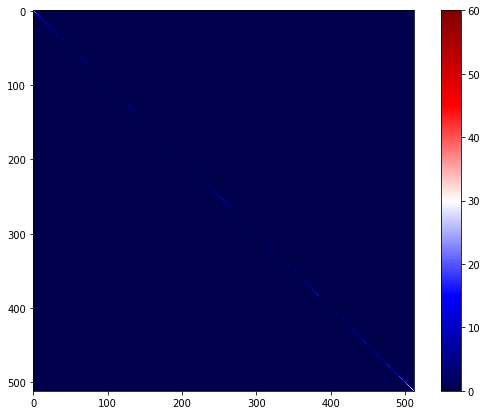

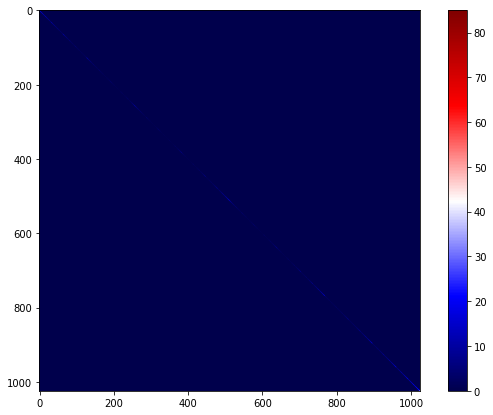

In [ ]:
for i in range(2,11):
  H = Get_H(0, i)
  plt.subplots(figsize=(10, 7))
  plt.imshow(H,cmap = 'seismic')
  plt.colorbar()

In [ ]:
H6 = Get_H(0.1, 6)
eig_values = torch.eig(H6, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)
M = torch.zeros(2**6, 2**6)
for i in range(2**6):
  for j in range(2**6):
    M[63 - i, 63 - j] = H6[i,j]
eig_values = torch.eig(M, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)

tensor(-2.5172)
tensor(-2.5172)


tensor(1.8500) tensor(7.2000)
tensor([[ 1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  3.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  3.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  5.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  5.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0

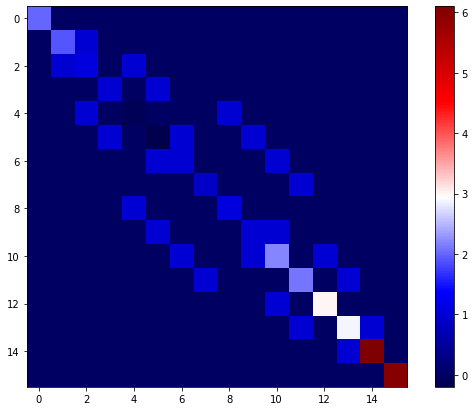

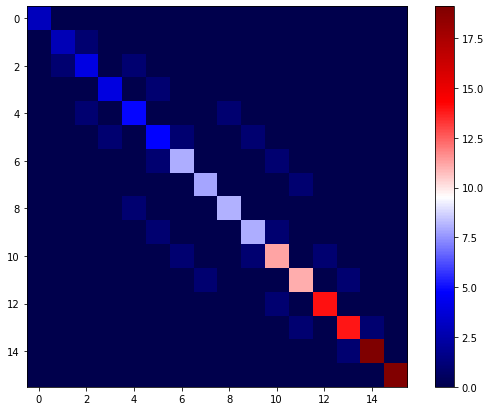

In [ ]:

H10 = Get_H(0.1, 6)
H9 = Get_H(0.1, 5)
T = torch.zeros(2**5, 2**5)
Y = torch.zeros(2**5, 2**5)
for i in range(2**5):
  for j in range(2**5):
    T[2**5 - 1 -i, 2**5 - 1 -j] = H10[i,j]

for i in range(2**5):
  for j in range(2**5):
    Y[i, j] = H10[i + 2**5, j + 2**5]

print(H9[14, 14], Y[14,14])
I = torch.eye(2**5) * 0.05

#print(H9 - T)
T1 = torch.zeros(2**4, 2**4)
for i in range(2**4):
  for j in range(2**4):
    T1[ i, j] = H10[i + 48, j + 48]

H4 =  Get_H(0.1, 4)
print(T1 - H4, 'T')

plt.subplots(figsize=(10, 7))
plt.imshow(H4,cmap = 'seismic')
plt.colorbar()
plt.subplots(figsize=(10, 7))
plt.imshow(T1,cmap = 'seismic')
plt.colorbar()
I = torch.eye(2**5) * 0.05


torch.Size([20]) torch.Size([20])
tensor(-2.5172)
torch.Size([6]) torch.Size([6])
tensor([[0.1000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.1000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.1000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.1000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1000]])


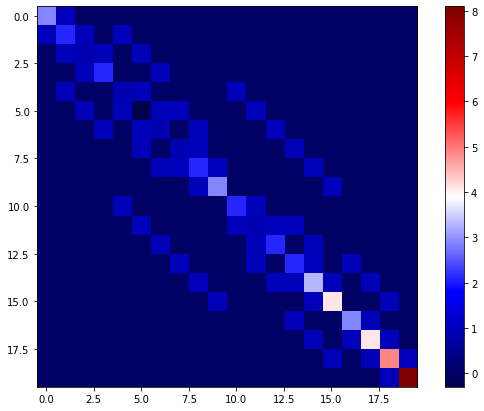

In [ ]:
#для хороших матриц тоже есть закономернсть
number_of_qubits = 6
basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
      #r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        basis[r][i] = float(p[i])
    r -= 1
sum_spin = math.ceil((number_of_qubits - 1) / 2 )
  #print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
  #print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch
  #H = Get_H(0.1, j)
m = 0.1
M = matrix(good_batch.to(device))
plt.subplots(figsize=(10, 7))
plt.imshow(M.cpu(),cmap = 'seismic')
  #plt.imshow(H,cmap = 'seismic')
plt.colorbar()
eig_values = torch.eig(M, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)
T = torch.zeros(6,6).to(device)
for i in range(6):
  for j in range(6):
    T[i,j] = M[i+4, j + 4]


number_of_qubits = 4
basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
      #r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        basis[r][i] = float(p[i])
    r -= 1
sum_spin = math.ceil((number_of_qubits - 1) / 2 )
  #print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
  #print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch
  #H = Get_H(0.1, j)
m = 0.1
M = matrix(good_batch.to(device))
print(M - T)

In [ ]:
#6-4

In [ ]:
H6 = Get_H(0.1, 6)
eig_values = torch.eig(H6, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)
H4 = Get_H(0.1, 4)
eig_values = torch.eig(H4, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)

tensor(-2.5172)
tensor(-1.5791)


In [ ]:
T = torch.zeros(8,8)
for i in range(8):
  for j in range(8):
    T[7-i,7-j] = H6[i,j]
H3 = Get_H(0.1, 3)
print(T)
print(H3)
print(T - H3)

tensor([[ 2.9000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  3.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  1.0000,  3.8000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  3.9000,  0.0000,  1.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  1.0000,  0.0000,  7.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  7.1000,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  9.9000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, 10.0000]])
tensor([[ 0.9500,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  1.0500,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  1.0000, -0.1500,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000, -0.0500,  0.0000,  1.0000,  0.0000,  0.0000],
        [ 0.000

torch.Size([48, 48])
tensor(-2.5146)


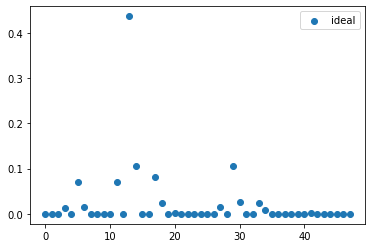

tensor(-2.5172)


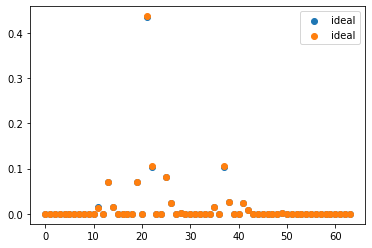

tensor(-1.6791)


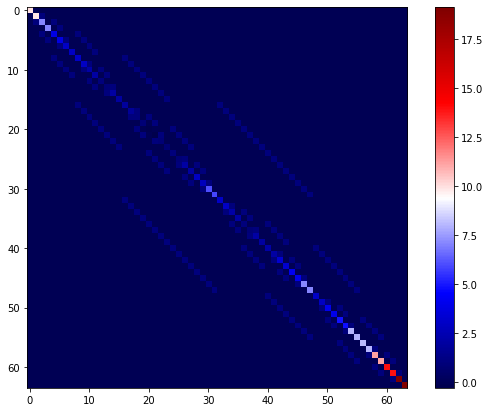

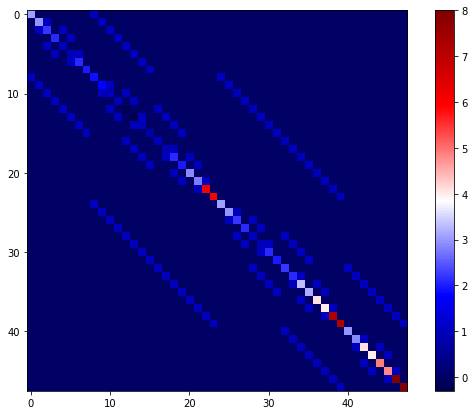

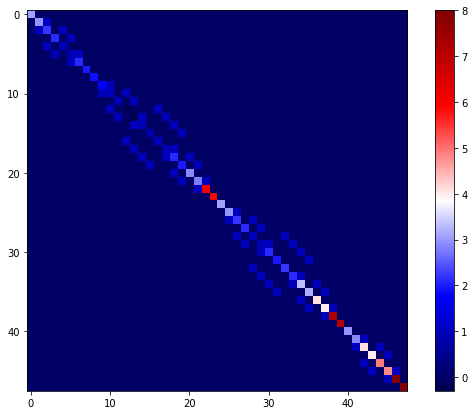

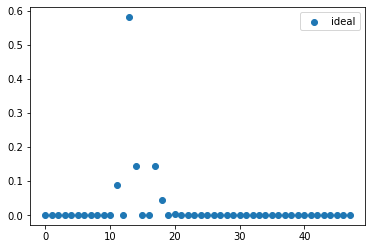

In [ ]:
i = torch.arange(2**3, 56)
j = torch.arange(2**3, 56)
M = torch.zeros(48,48)
print(M.shape)
for i in range(48):
  for j in range(48):
    M[i,j] = H6[i+2**3, j+2**3]

eig_values = torch.eig(M, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(M, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[1]
R = eig_vector[:,m].reshape(-1)
print(c)
x = torch.arange(R.shape[0])
way = torch.zeros(2**6)

way[x + 2**3] = R[x]
fig, ax = plt.subplots()
x = torch.arange(R.shape[0])
ax.scatter(x, R**2, alpha = 1, label='ideal')
ax.legend()
plt.show()

eig_values = torch.eig(H6, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H6, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[1]
R = eig_vector[:,m].reshape(-1)
print(c)

fig, ax = plt.subplots()
x = torch.arange(R.shape[0])
ax.scatter(x, R**2, alpha = 1, label='ideal')
ax.scatter(x, way**2, alpha = 1, label='ideal')
ax.legend()
plt.show()
plt.subplots(figsize=(10, 7))
plt.imshow(H6, cmap = 'seismic')
plt.colorbar()
plt.subplots(figsize=(10, 7))
plt.imshow(M, cmap = 'seismic')
plt.colorbar()
for i  in range(8):
  for j in range(8,16+8):
    M[i,j] = 0
for j  in range(8):
  for i in range(8,16+8):
    M[i,j] = 0
for i  in range(24,40):
  for j in range(8,24):
    M[i,j] = 0
for j  in range(24,40):
  for i in range(8,24):
    M[i,j] = 0

for i  in range(40,48):
  for j in range(32,40):
    M[i,j] = 0
for j  in range(40,48):
  for i in range(32,40):
    M[i,j] = 0
plt.subplots(figsize=(10, 7))
plt.imshow(M, cmap = 'seismic')
plt.colorbar()

eig_values = torch.eig(M, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(M, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[1]
R = eig_vector[:,m].reshape(-1)
print(c)

fig, ax = plt.subplots()
x = torch.arange(R.shape[0])
ax.scatter(x, R**2, alpha = 1, label='ideal')
ax.legend()
plt.show()

In [ ]:
#10-8

In [ ]:
H8 = Get_H(0.1, 10)
eig_values = torch.eig(H8, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)
H4 = Get_H(0.1, 8)
eig_values = torch.eig(H4, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)

tensor(-4.4024)
tensor(-3.4595)


torch.Size([640, 640])
tensor(-4.3932)


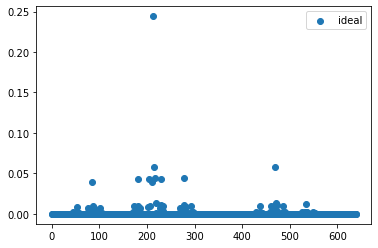

tensor(-4.4024)


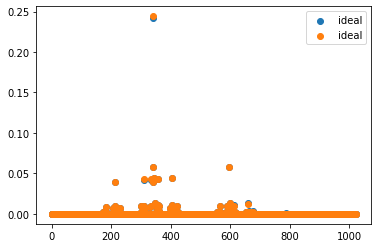

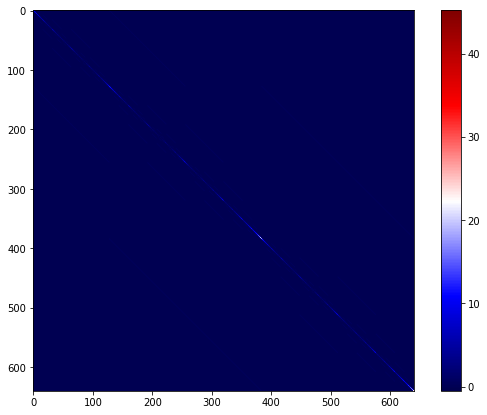

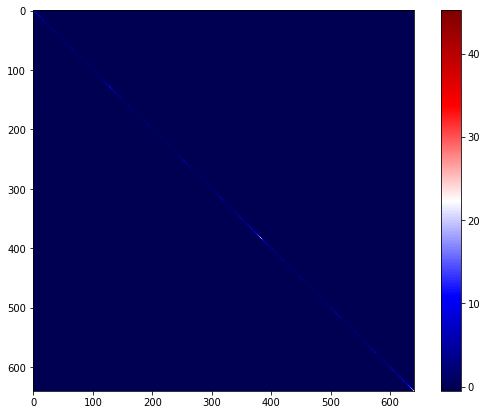

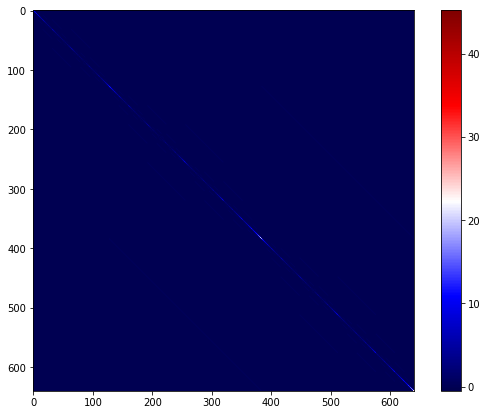

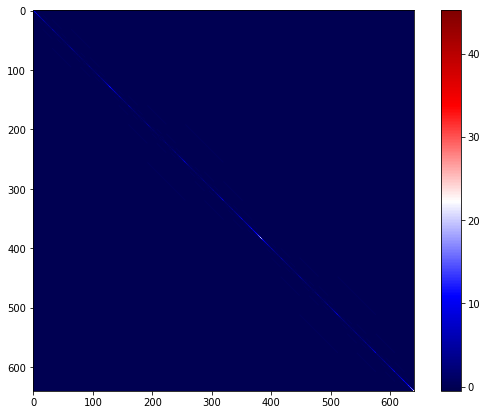

In [ ]:
i = torch.arange(2**7, 768)
j = torch.arange(2**7, 768)
M = torch.zeros(640,640)
print(M.shape)
for i in range(640):
  for j in range(640):
    M[i,j] = H8[i+2**7, j+2**7]

eig_values = torch.eig(M, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(M, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[1]
R = eig_vector[:,m].reshape(-1)
print(c)
x = torch.arange(R.shape[0])
way = torch.zeros(2**10)

way[x + 128] = R[x]
fig, ax = plt.subplots()
x = torch.arange(R.shape[0])
ax.scatter(x, R**2, alpha = 1, label='ideal')
ax.legend()
plt.show()

eig_values = torch.eig(H8, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H8, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[1]
R = eig_vector[:,m].reshape(-1)
print(c)

fig, ax = plt.subplots()
x = torch.arange(R.shape[0])
ax.scatter(x, R**2, alpha = 1, label='ideal')
ax.scatter(x, way**2, alpha = 1, label='ideal')
ax.legend()
plt.show()

plt.subplots(figsize=(10, 7))
plt.imshow(M, cmap = 'seismic')
plt.colorbar()
for i  in range(128):
  for j in range(128,640):
    M[i,j] = 0
plt.subplots(figsize=(10, 7))
plt.imshow(M, cmap = 'seismic')
plt.colorbar()
for j  in range(128):
  for i in range(128,640):
    M[i,j] = 0
plt.subplots(figsize=(10, 7))
plt.imshow(M, cmap = 'seismic')
plt.colorbar()
for i  in range(384,640):
  for j in range(128,384):
    M[i,j] = 0
for j  in range(384,640):
  for i in range(128,384):
    M[i,j] = 0
plt.subplots(figsize=(10, 7))
plt.imshow(M, cmap = 'seismic')
plt.colorbar()

In [ ]:
eig_values = torch.eig(M, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)

tensor(-3.5595)


In [ ]:
I = torch.eye(640,640)
for i in range(0,128):
  I[i,i] *= -1.05
for i in range(128,384):
  I[i,i] *= 0.1
for i in range(384,640):
  I[i,i] *= -1.1
M = M + I
eig_values = torch.eig(M, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)

tensor(-4.7307)


torch.Size([16, 16])
tensor(-1.6791)
torch.Size([16, 16])
tensor(-0.4791)
tensor([[1.2000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 1.2000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.2000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 1.2000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 1.2000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.2000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0

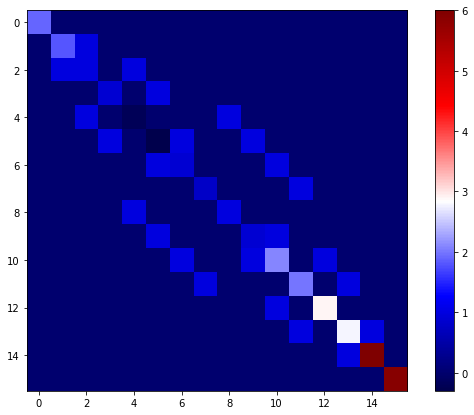

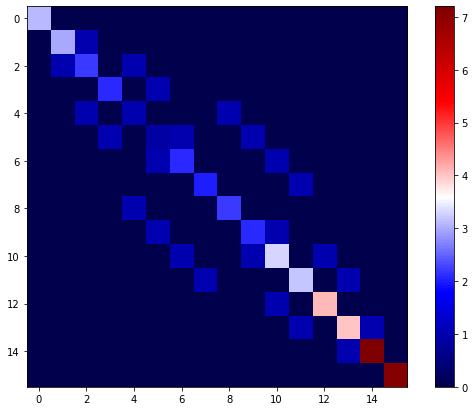

In [ ]:
i = torch.arange(16, 32)
j = torch.arange(16, 32)
M = torch.zeros(16,16)
print(M.shape)
for i in range(16):
  for j in range(16):
    M[i,j ] = H8[i+16, j+16]

eig_values = torch.eig(M, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)
plt.subplots(figsize=(10, 7))
plt.imshow(M, cmap = 'seismic')
plt.colorbar()
i = torch.arange(32, 48)
j = torch.arange(32, 48)
M2 = torch.zeros(16,16)
print(M.shape)
for i in range(16):
  for j in range(16):
    M2[i,j ] = H8[i+32, j+32]

eig_values = torch.eig(M2, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)
plt.subplots(figsize=(10, 7))
plt.imshow(M2, cmap = 'seismic')
plt.colorbar()
print(M2-M)
print(M[0,0], M2[0,0])
print(M - H4)
print(M2 - H4)

In [ ]:
H8 = Get_H(0.1, 8)
eig_values = torch.eig(H8, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)
H6 = Get_H(0.1, 6)
eig_values = torch.eig(H6, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)
H5 = Get_H(0.1, 5)
print(H5)

tensor(-3.4595)
tensor(-2.5172)
tensor([[ 5.9500,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  6.0500,  1.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  1.0000,  2.8500,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  7.1500,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  9.9500,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 10.0500]])


In [ ]:
M = torch.zeros(32,32)
for i in range(32):
  for j in range(32):
    M[i,j] = H5[31-i, 31 - j] 
print(H5)
print(M)

tensor([[ 5.9500,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  6.0500,  1.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  1.0000,  2.8500,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  7.1500,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  9.9500,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 10.0500]])
tensor([[10.0500,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  9.9500,  1.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  1.0000,  7.1500,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  2.8500,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  6.0500,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  5.9500]])


In [ ]:
i = torch.arange(2**5, 2**6)
j = torch.arange(2**5, 2**6)
S = torch.zeros(32,32)
print(M.shape)
for i in range(32):
  for j in range(32):
    S[i,j ] = H8[i+2**5, j+2**5]
print((S-M))

torch.Size([32, 32])
tensor([[1.0500, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 1.0500, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.0500,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 1.0500, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.0500, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.0500]])


torch.Size([64, 64])
tensor(-2.6172)
torch.Size([64, 64])
tensor(-1.4172)
tensor([[1.2000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 1.2000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.2000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 1.2000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.2000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.2000]])
tensor(9.9000) tensor(11.1000)
tensor([[-0.1000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000, -0.1000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000, -0.1000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ..., -0.1000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.1000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.1000]])
tensor([[1.1000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],

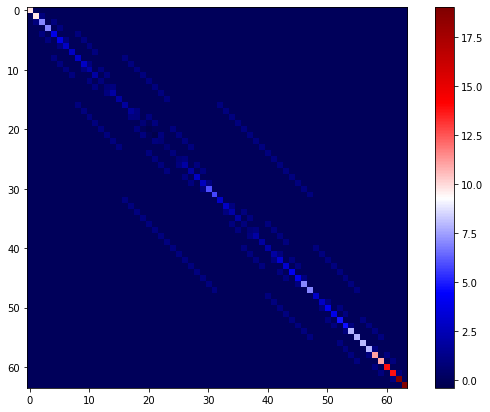

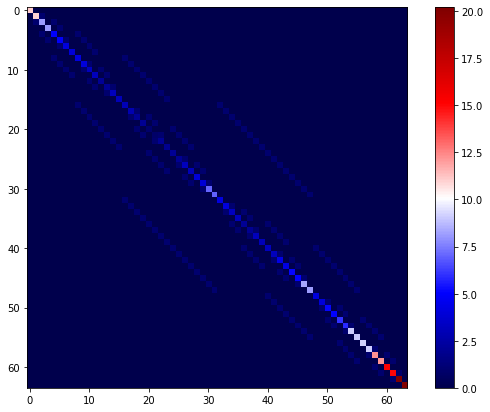

In [ ]:
i = torch.arange(2**6, 2**7)
j = torch.arange(2**6, 2**7)
M = torch.zeros(64,64)
print(M.shape)
for i in range(64):
  for j in range(64):
    M[i,j ] = H8[i+2**6, j+2**6]

eig_values = torch.eig(M, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)
plt.subplots(figsize=(10, 7))
plt.imshow(M, cmap = 'seismic')
plt.colorbar()
i = torch.arange(2**7, 2**7 + 2**6)
j = torch.arange(2**7, 2**6 +2**7)
M2 = torch.zeros(64,64)
print(M.shape)
for i in range(64):
  for j in range(64):
    M2[i,j ] = H8[i+2**7, j+2**7]

eig_values = torch.eig(M2, eigenvectors = True)[0][:, 0]
c = eig_values.min()
print(c)
plt.subplots(figsize=(10, 7))
plt.imshow(M2, cmap = 'seismic')
plt.colorbar()
print(M2-M)
print(M[0,0], M2[0,0])
print(M - H6)
print(M2 - H6)

In [ ]:
p = ((H8).abs() != 0).nonzero()
print(p.shape)
row = torch.zeros(p.shape[0])
col = torch.zeros(p.shape[0])
data = torch.zeros(p.shape[0])
row[:] = p[:,0]
col[:] = p[:,1]
row = row.long()
col = col.long()
for i in range(p.shape[0]):
  data[i] = H8[row[i], col[i]]

torch.Size([1152, 2])


In [ ]:
row10 = torch.zeros(p.shape[0])
col10 = torch.zeros(p.shape[0])
data10 = torch.zeros(p.shape[0])
row10[:] = row[:] + 2**8
col10[:] = col[:] + 2**8

In [ ]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
eigenvalues, eigenvectors = eigsh(csr_matrix((data.cpu(), (row.cpu(), col.cpu())), shape=(2**8, 2**8)).astype(float), k=1, which = 'SA')
print(eigenvalues)

[-3.45945015]


(1024,)


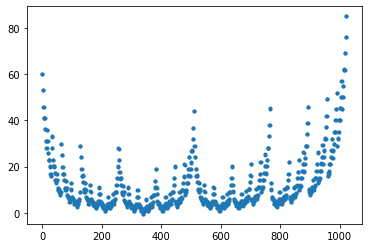

In [ ]:
j = torch.arange(1024)
x = H[j,j].numpy()
print(x.shape)
plt.plot(x,'.')

In [ ]:
ind = (torch.abs(H) > 0.001).nonzero()
print(ind.shape)

torch.Size([5632, 2])


In [ ]:
print(H.max())
print(H.min())
x = H[ind[:,0], ind[:,1]].flatten().numpy()
y = H.flatten().numpy()
print(x[5])

tensor(85.1000)
tensor(-0.5000)
1.0


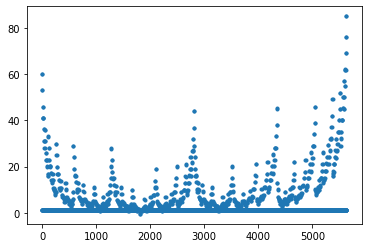

In [ ]:
plt.plot(x,'.')

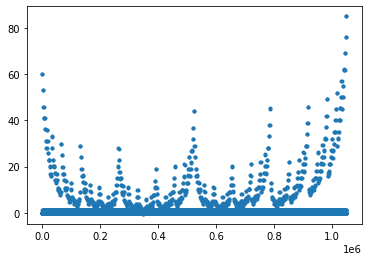

In [ ]:
plt.plot(y,'.')

In [ ]:
tri = [4.1856, 4.1790, 4.1814, 4.1805]
dva = [6.1071, 6.1323, 6.1232, 6.1265]
odin = [1.4591, 1.4674, 1.4644, 1.4655]


In [ ]:
tri.append(pick/pick2)
dva.append(pick/pick3)
odin.append(pick2/pick3)
print(tri)

[4.1856, 4.179, 4.1814, 4.1805, 4.180848, 4.1807094, 4.1807556]


In [ ]:
tri.insert(0,pick/pick2)
dva.insert(0,pick/pick3)
odin.insert(0,pick2/pick3)

In [ ]:
tri.insert(0,0)
dva.insert(0,0)
odin.insert(0,0)

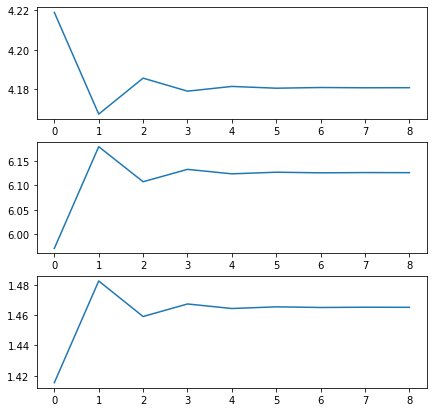

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(7, 7))
x = np.arange(0,9)

axs[0].plot(x, tri)

axs[1].plot(x, dva)

axs[2].plot(x, odin)

In [ ]:
from google.colab import files
files.download('Gr_st.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
num_12 = np.load('number_of_qubits_12.npy')**2

NameError: ignored

In [ ]:
import sys
sys.path.append('/home/alyona/jupyter/neat_folder')

In [ ]:
!mkdir -p drive
!google-drive-ocamlfuse drive

/bin/bash: google-drive-ocamlfuse: command not found


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ls

anscombe.json*                mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md*


In [ ]:
cd sample_data/

/content/sample_data


SyntaxError: ignored